In [4]:
import torch
import gpytorch
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from torch.utils.data import TensorDataset, DataLoader
from pyproj import Transformer
from sklearn.metrics import pairwise_distances
from scipy.interpolate import RegularGridInterpolator
from torch_geometric.data import Data




In [5]:
#read in dataset. 
with open('imputed_study_data.pkl', 'rb') as f:
    df=pickle.load(f)

In [6]:
#convert to daily values 
df['date'] = df['time'].dt.tz_convert(None).dt.date
agg_cols = [
    'value',
    'temperature_2m','relative_humidity_2m','dew_point_2m',
    'wind_speed_10m','wind_direction_10m','surface_pressure','precipitation'
]
grouped = df.groupby(['location_id','station_lat','station_lon','date'], as_index=False)[agg_cols].mean()

grouped.head(5)

,location_id,station_lat,station_lon,date,value,temperature_2m,relative_humidity_2m,dew_point_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation
0,2622586,37.580167,127.044856,2024-12-01,20.541667,0.770833,95.375000,0.062500,2.983333,94.583333,999.987500,0.012500
1,2622586,37.580167,127.044856,2024-12-02,21.416667,4.108333,83.958333,1.487500,7.937500,206.416667,999.816667,0.020833
2,2622586,37.580167,127.044856,2024-12-03,6.583333,-0.920833,59.791667,-8.079167,6.525000,269.875000,1007.179167,0.000000
3,2622586,37.580167,127.044856,2024-12-04,11.128392,0.145833,66.041667,-5.887500,4.466667,290.041667,1006.158333,0.000000
4,2622586,37.580167,127.044856,2024-12-05,8.666667,1.191667,72.083333,-3.695833,5.216667,256.791667,1001.008333,0.000000


In [12]:
#now build the network edge list. 
#we build one network per day. 
#edges are treated as continuous values between zero and one.
#first the RBF kernel is used to compute similarity and then KNN is applied to sparsify the graph. 


# --- CONFIG ---
tau = 0.1   # temperature for softmax (controls sharpness)
sigma = 1.0

predictor_cols = [
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
    'wind_speed_10m', 'wind_direction_10m', 'surface_pressure',
    'precipitation'
]

def rbf_similarity(X, sigma=1.0):
    D = pairwise_distances(X, metric='euclidean')
    return np.exp(-(D**2) / (2 * sigma**2))

def soft_knn_adjacency(S, tau=0.1):
    expS = np.exp(S / tau)
    P = expS / expS.sum(axis=1, keepdims=True)
    return 0.5 * (P + P.T)   # symmetric

# --- BUILD DAILY GRAPHS ---
daily_graphs = {}

for date, df_day in grouped.groupby('date'):
    date_str = pd.to_datetime(date).strftime('%Y-%m-%d')   # <-- FIX HERE

    node_ids = df_day['location_id'].values
    X = df_day[predictor_cols].values

    S = rbf_similarity(X, sigma=sigma)
    A = soft_knn_adjacency(S, tau=tau)

    daily_graphs[date_str] = {
        'node_ids': node_ids,
        'X': X,
        'A': A
    }



In [17]:
#now make continuous fields. 



predictor_cols = [
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
    'wind_speed_10m', 'wind_direction_10m', 'surface_pressure',
    'precipitation'
]

def build_continuous_fields(grouped, grid_res=100):
    """
    Build continuous predictor fields for each day using bilinear interpolation.
    Returns: dict[date_str] -> {
        'interpolators': {predictor: callable(lat, lon)},
        'sensor_data': original df for that day
    }
    """
    continuous_fields = {}

    # Extract global bounding box
    all_lats = grouped['station_lat'].values
    all_lons = grouped['station_lon'].values

    lat_min, lat_max = all_lats.min(), all_lats.max()
    lon_min, lon_max = all_lons.min(), all_lons.max()

    # Build regular grid
    lat_grid = np.linspace(lat_min, lat_max, grid_res)
    lon_grid = np.linspace(lon_min, lon_max, grid_res)

    for date, df_day in grouped.groupby('date'):
        date_str = pd.to_datetime(date).strftime('%Y-%m-%d')

        # Extract sensor coordinates + predictors
        lats = df_day['station_lat'].values
        lons = df_day['station_lon'].values

        interpolators = {}

        # Build interpolator for each predictor
        for col in predictor_cols:
            values = df_day[col].values

            # Interpolate onto regular grid
            # We use scipy's griddata for scattered -> grid
            from scipy.interpolate import griddata
            grid_vals = griddata(
                points=np.column_stack([lats, lons]),
                values=values,
                xi=np.meshgrid(lat_grid, lon_grid, indexing='ij'),
                method='linear'
            )

            # Fill NaNs (outside convex hull) with nearest
            nan_mask = np.isnan(grid_vals)
            if nan_mask.any():
                grid_vals[nan_mask] = griddata(
                    points=np.column_stack([lats, lons]),
                    values=values,
                    xi=np.meshgrid(lat_grid, lon_grid, indexing='ij'),
                    method='nearest'
                )[nan_mask]

            # Build bilinear interpolator
            interp = RegularGridInterpolator(
                (lat_grid, lon_grid),
                grid_vals,
                bounds_error=False,
                fill_value=None
            )

            interpolators[col] = interp

        # Store everything
        continuous_fields[date_str] = {
            'interpolators': interpolators,
            'sensor_data': df_day
        }

    return continuous_fields


# --- BUILD THE CONTINUOUS FIELDS ---
continuous_fields = build_continuous_fields(grouped)



In [20]:
#now train a graph convolutional model on the daily graphs. 



# daily_graphs: {date_str: {'node_ids', 'X', 'A'}}
# grouped: your original dataframe with 'date', 'location_id', 'value'

def build_spatiotemporal_samples(daily_graphs, grouped, start_date, end_date):
    """
    Build (X_t, edge_index, edge_weight, y_{t+1}) samples between start_date and end_date (inclusive).
    Dates are 'YYYY-MM-DD' strings.
    """
    # Filter and sort dates
    all_dates = sorted(daily_graphs.keys())
    all_dates = [d for d in all_dates if start_date <= d <= end_date]

    # Build mapping date -> PM2.5 per location_id
    pm25_by_date = {}
    for date, df_day in grouped.groupby('date'):
        date_str = pd.to_datetime(date).strftime('%Y-%m-%d')
        if date_str in all_dates:
            pm25_by_date[date_str] = df_day.set_index('location_id')['value']

    samples = []

    for i in range(len(all_dates) - 1):
        d_t = all_dates[i]
        d_tp1 = all_dates[i + 1]

        g_t = daily_graphs[d_t]
        node_ids_t = g_t['node_ids']
        X_t = g_t['X']
        A_t = g_t['A']

        # PM2.5 at t and t+1 aligned by location_id
        pm25_t = pm25_by_date[d_t].reindex(node_ids_t).values
        pm25_tp1 = pm25_by_date[d_tp1].reindex(node_ids_t).values  # assume same nodes; reindex handles order

        # Input node features: predictors_t + pm25_t
        X_in = np.concatenate([X_t, pm25_t[:, None]], axis=1)  # shape (N, D+1)

        # Build edge_index and edge_weight from A_t
        src, dst = np.nonzero(A_t)
        edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)
        edge_weight = torch.tensor(A_t[src, dst], dtype=torch.float32)

        # Targets: PM2.5 at t+1
        y = torch.tensor(pm25_tp1, dtype=torch.float32)

        data = Data(
            x=torch.tensor(X_in, dtype=torch.float32),
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=y,
        )
        data.node_ids = node_ids_t
        data.date_t = d_t
        data.date_tp1 = d_tp1

        samples.append(data)

    return samples

# Example: train on December 2024
train_samples = build_spatiotemporal_samples(
    daily_graphs,
    grouped,
    start_date='2024-12-01',
    end_date='2024-12-31'
)


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class SpatioTemporalGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1):
        super().__init__()
        self.gcn = GCNConv(in_channels, hidden_channels)
        self.gru = nn.GRU(hidden_channels, hidden_channels, batch_first=True)
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, data_seq):
        """
        data_seq: list of Data objects [day_t, day_t_minus1, ...] or just [day_t]
        For now, we assume length-1 sequences: [data_t].
        """
        # Stack node features for sequence dimension
        # Here: seq_len = 1, so we just add a dimension
        x = data_seq[0].x
        edge_index = data_seq[0].edge_index
        edge_weight = data_seq[0].edge_weight

        # Spatial GNN
        h = F.relu(self.gcn(x, edge_index, edge_weight))

        # Add sequence dimension: (batch=1, seq_len=1, nodes*feat) is awkward,
        # so we treat nodes as "batch" for GRU: (nodes, seq_len, feat)
        h_seq = h.unsqueeze(1)  # (N, 1, hidden)

        # GRU over time dimension (here length 1, but extensible)
        h_out, _ = self.gru(h_seq)  # (N, 1, hidden)
        h_last = h_out[:, -1, :]    # (N, hidden)

        # Node-wise prediction
        y_hat = self.lin(h_last).squeeze(-1)  # (N,)
        return y_hat


In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

in_channels = train_samples[0].x.shape[1]   # predictors + pm25_t
hidden_channels = 64

model = SpatioTemporalGNN(in_channels, hidden_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

def train_epoch(samples):
    model.train()
    total_loss = 0.0

    for data in samples:
        data = data.to(device)
        optimizer.zero_grad()

        # For now, sequence length = 1: [data_t]
        y_hat = model([data])
        loss = loss_fn(y_hat, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(samples)

# Example: train for a few epochs
for epoch in range(1, 51):
    loss = train_epoch(train_samples)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train MSE: {loss:.4f}")


Epoch 010 | Train MSE: 219.5820
Epoch 020 | Train MSE: 127.2233
Epoch 030 | Train MSE: 94.6341
Epoch 040 | Train MSE: 85.2630
Epoch 050 | Train MSE: 83.0491


In [23]:
train_samples_jan = build_spatiotemporal_samples(
    daily_graphs,
    grouped,
    start_date='2025-01-01',
    end_date='2025-01-31'
)


In [11]:
# requirements:
# pip install requests pandas numpy tqdm pyarrow pyproj

import os
import time
import math
import random
import requests
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import timedelta, datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from pyproj import Transformer
from threading import Lock

# -------------------------
# User inputs (edit as needed)
# -------------------------
BBOX = (128.8, 34.8, 129.3, 35.3)   # (min_lon, min_lat, max_lon, max_lat)
lengthscale_km = 4.5                 # spatial lengthscale in km (used to set spacing if building grid)
spacing_km = lengthscale_km / 2.0
cell_size_m = spacing_km * 1000.0

# Try to use existing grid_centers or centers; otherwise build grid from BBOX
try:
    grid_centers  # noqa: F821
    use_existing_grid = True
except NameError:
    try:
        centers  # noqa: F821
        grid_centers = centers
        use_existing_grid = True
    except NameError:
        use_existing_grid = False

# -------------------------
# Open‑Meteo daily endpoint and variables (deduped)
# -------------------------
ARCHIVE_BASE = "https://archive-api.open-meteo.com/v1/archive"
daily_vars = [
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "dew_point_2m_mean",
    "windspeed_10m_mean",
    "winddirection_10m_dominant",
    "surface_pressure_mean",
    "precipitation_sum"
]
# ensure uniqueness while preserving order
_seen = set()
daily_vars = [x for x in daily_vars if not (x in _seen or _seen.add(x))]

timezone = "UTC"

# Date range (uses your provided last timestamp)
first_timestamp = pd.Timestamp('2024-12-01 00:00:00+0000', tz='UTC')
start_date = first_timestamp.tz_convert("UTC").date().isoformat()
last_timestamp = pd.Timestamp("2025-08-31 23:00:00+0000", tz="UTC")
end_date = last_timestamp.tz_convert("UTC").date().isoformat()

# Output and fetch settings (safer defaults)
out_dir = "open_meteo_grid_daily_direct"
os.makedirs(out_dir, exist_ok=True)
requests_per_second = 1.0   # safer default; increase only if you confirm API capacity
max_workers = 4            # lower concurrency to reduce bursts
max_retries = 5
retry_backoff_base = 2.0   # base for exponential backoff
max_backoff_seconds = 300  # cap backoff to 5 minutes

# -------------------------
# Build grid_centers if needed (square metric grid using AEQD projection)
# -------------------------
if not use_existing_grid:
    min_lon, min_lat, max_lon, max_lat = BBOX
    center_lon = (min_lon + max_lon) / 2.0
    center_lat = (min_lat + max_lat) / 2.0

    proj_str = f"+proj=aeqd +lat_0={center_lat} +lon_0={center_lon} +units=m +datum=WGS84 +no_defs"
    transformer_to_m = Transformer.from_crs("epsg:4326", proj_str, always_xy=True)
    transformer_to_lonlat = Transformer.from_crs(proj_str, "epsg:4326", always_xy=True)

    def lonlat_to_m(lon, lat):
        x, y = transformer_to_m.transform(lon, lat)
        return float(x), float(y)

    def m_to_lonlat(x, y):
        lon, lat = transformer_to_lonlat.transform(x, y)
        return float(lon), float(lat)

    x_min, y_min = lonlat_to_m(min_lon, min_lat)
    x_max, y_max = lonlat_to_m(max_lon, max_lat)
    x0, x1 = min(x_min, x_max), max(x_min, x_max)
    y0, y1 = min(y_min, y_max), max(y_min, y_max)

    n_cols = int(math.ceil((x1 - x0) / cell_size_m))
    n_rows = int(math.ceil((y1 - y0) / cell_size_m))
    grid_centers = []
    for i in range(n_cols):
        for j in range(n_rows):
            x_left = x0 + i * cell_size_m
            x_right = x0 + (i + 1) * cell_size_m
            y_bottom = y0 + j * cell_size_m
            y_top = y0 + (j + 1) * cell_size_m
            cx = (x_left + x_right) / 2.0
            cy = (y_bottom + y_top) / 2.0
            lonc, latc = m_to_lonlat(cx, cy)
            grid_centers.append((lonc, latc))
    print(f"Built grid: {n_cols} cols × {n_rows} rows = {len(grid_centers)} cells; spacing {spacing_km:.3f} km")
else:
    # normalize grid_centers formats
    if isinstance(grid_centers, np.ndarray):
        grid_centers = [tuple(x) for x in grid_centers.tolist()]
    elif isinstance(grid_centers, pd.DataFrame):
        if {'lon','lat'}.issubset(set(grid_centers.columns)):
            grid_centers = list(zip(grid_centers['lon'].values, grid_centers['lat'].values))
        else:
            raise RuntimeError("If grid_centers is a DataFrame it must contain 'lon' and 'lat' columns.")
    print(f"Using existing grid_centers with {len(grid_centers)} cells")

# Quick validation: ensure tuples are (lon, lat). If many entries look swapped, offer automatic swap.
def looks_like_latlon_swapped(sample):
    lon, lat = sample
    return abs(lon) <= 90 and abs(lat) <= 180 and not (-180 <= lon <= 180 and -90 <= lat <= 90)

if len(grid_centers) > 0:
    first = grid_centers[0]
    if looks_like_latlon_swapped(first):
        print("Detected grid_centers likely in (lat, lon) order; swapping to (lon, lat).")
        grid_centers = [(lonlat[1], lonlat[0]) for lonlat in grid_centers]

# -------------------------
# Helpers for daily fetch with retries, 429 handling, and caching
# -------------------------
def build_params_daily(lat, lon, start_iso, end_iso, daily_vars, timezone="UTC"):
    return {
        "latitude": float(lat),
        "longitude": float(lon),
        "start_date": start_iso,
        "end_date": end_iso,
        "daily": ",".join(daily_vars),
        "timezone": timezone
    }

SESSION = requests.Session()
RATE_LOCK = Lock()
LAST_REQUEST_TS = 0.0

def throttle():
    """Global pacing to respect requests_per_second across threads."""
    global LAST_REQUEST_TS
    with RATE_LOCK:
        min_interval = 1.0 / max(1.0, requests_per_second)
        now = time.time()
        wait = LAST_REQUEST_TS + min_interval - now
        if wait > 0:
            time.sleep(wait)
        LAST_REQUEST_TS = time.time()

def _sleep_with_jitter(seconds):
    """Sleep with small jitter to avoid synchronized retries."""
    jitter = random.uniform(0.0, 0.25 * seconds) if seconds > 0 else 0.0
    time.sleep(seconds + jitter)

def fetch_daily_with_retries(lat, lon, start_iso, end_iso, daily_vars, timezone="UTC"):
    params = build_params_daily(lat, lon, start_iso, end_iso, daily_vars, timezone)
    attempt = 0
    while attempt <= max_retries:
        try:
            throttle()
            r = SESSION.get(ARCHIVE_BASE, params=params, timeout=60)
            if r.status_code == 200:
                try:
                    return r.json()
                except ValueError:
                    raise RuntimeError(f"Invalid JSON response for ({lat},{lon})")
            elif r.status_code == 429:
                # Rate limited: honor Retry-After if present, otherwise exponential backoff
                retry_after = r.headers.get("Retry-After")
                if retry_after is not None:
                    try:
                        wait = float(retry_after)
                    except Exception:
                        # sometimes Retry-After is a HTTP-date; fallback to a safe wait
                        wait = min(60.0, retry_backoff_base ** (attempt + 1))
                    wait = min(wait, max_backoff_seconds)
                    print(f"429 for ({lat},{lon}) — server asked to wait {wait}s (Retry-After). Attempt {attempt+1}/{max_retries}")
                    _sleep_with_jitter(wait)
                else:
                    # exponential backoff with jitter
                    wait = min(max_backoff_seconds, retry_backoff_base ** (attempt + 1))
                    print(f"429 for ({lat},{lon}) — backing off {wait}s (no Retry-After). Attempt {attempt+1}/{max_retries}")
                    _sleep_with_jitter(wait)
                attempt += 1
                continue
            else:
                text = r.text[:1000] if r.text else ""
                print(f"API returned status {r.status_code} for ({lat},{lon}) start={start_iso} end={end_iso}: {text}")
                r.raise_for_status()
        except requests.RequestException as e:
            attempt += 1
            # exponential backoff with jitter for network errors
            wait = min(max_backoff_seconds, retry_backoff_base ** attempt)
            print(f"Network/request error for ({lat},{lon}) attempt {attempt}/{max_retries}: {e}. Backing off {wait}s")
            _sleep_with_jitter(wait)
            if attempt > max_retries:
                raise RuntimeError(f"Failed to fetch daily ({lat},{lon}) after {max_retries} retries: {e}")
        except Exception as e:
            attempt += 1
            wait = min(max_backoff_seconds, retry_backoff_base ** attempt)
            print(f"Unexpected error for ({lat},{lon}) attempt {attempt}/{max_retries}: {e}. Backing off {wait}s")
            _sleep_with_jitter(wait)
            if attempt > max_retries:
                raise RuntimeError(f"Failed to fetch daily ({lat},{lon}) after {max_retries} retries: {e}")
    raise RuntimeError("unreachable")

def safe_daily_path(cell_dir, idx):
    return os.path.join(cell_dir, f"cell_{idx:04d}_daily")

# -------------------------
# Parse daily payload into DataFrame (handles missing vars gracefully)
# -------------------------
def parse_daily_payload(payload, daily_vars):
    daily = payload.get("daily", {})
    times = daily.get("time", [])
    if len(times) == 0:
        return pd.DataFrame(columns=["date"] + daily_vars)
    try:
        df = pd.DataFrame({"date": pd.to_datetime(times)})
        for var in daily_vars:
            vals = daily.get(var)
            if vals is None:
                df[var] = np.nan
            else:
                df[var] = pd.to_numeric(vals, errors="coerce")
        df['date'] = pd.to_datetime(df['date']).dt.date
        return df
    except Exception as e:
        print("Failed to parse payload into DataFrame:", e)
        try:
            print("Payload daily keys:", list(daily.keys()))
            import json
            sample = {k: (daily.get(k)[:3] if isinstance(daily.get(k), list) else daily.get(k)) for k in list(daily.keys())[:10]}
            print(json.dumps(sample, default=str))
        except Exception:
            pass
        raise

# -------------------------
# Main: fetch full-range daily per cell (one request per cell), cache per-cell daily parquet/csv
# -------------------------
n_cells = len(grid_centers)
print(f"Fetching Open‑Meteo daily for {n_cells} cells from {start_date} to {end_date} (one request per cell)")

# pre-create date keys
start_dt = pd.to_datetime(start_date).date()
end_dt = pd.to_datetime(end_date).date()
all_dates = pd.date_range(start=start_dt, end=end_dt, freq="D").date.tolist()
data_by_day = {d.isoformat(): {} for d in all_dates}

def process_cell_daily(idx, lon, lat):
    cell_dir = os.path.join(out_dir, f"cell_{idx:04d}")
    os.makedirs(cell_dir, exist_ok=True)
    base_path = safe_daily_path(cell_dir, idx)
    parquet_path = base_path + ".parquet"
    csv_path = base_path + ".csv"

    # if cached parquet or csv exists, load and return
    if os.path.exists(parquet_path):
        try:
            df_cell = pd.read_parquet(parquet_path)
            if 'date' in df_cell.columns:
                df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date
            return idx, lon, lat, df_cell
        except Exception as e:
            print(f"Warning: failed to read parquet for cell {idx}: {e}")

    if os.path.exists(csv_path):
        try:
            df_cell = pd.read_csv(csv_path, parse_dates=["date"])
            if 'date' in df_cell.columns:
                df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date
            return idx, lon, lat, df_cell
        except Exception as e:
            print(f"Warning: failed to read csv for cell {idx}: {e}")

    # sanity check for coordinate ranges
    if not (-90.0 <= lat <= 90.0 and -180.0 <= lon <= 180.0):
        raise RuntimeError(f"Invalid coordinates for cell {idx}: lat={lat}, lon={lon}")

    # fetch daily range in one request (with robust retry/429 handling)
    payload = fetch_daily_with_retries(lat=lat, lon=lon, start_iso=start_date, end_iso=end_date, daily_vars=daily_vars, timezone=timezone)

    df_cell = parse_daily_payload(payload, daily_vars)

    # if API returned no rows, create full-range empty frame
    if df_cell.shape[0] == 0:
        df_cell = pd.DataFrame({"date": all_dates})
        for var in daily_vars:
            df_cell[var] = np.nan
    else:
        df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date

    # -------------------------
    # Safe reindexing: avoid duplicate 'date' column
    # -------------------------
    if 'date' in df_cell.columns:
        temp_index = pd.to_datetime(df_cell['date'])
        df_cell = df_cell.drop(columns=['date'])
    else:
        temp_index = pd.to_datetime(df_cell.index)

    df_cell = df_cell.set_index(temp_index).reindex(pd.to_datetime(all_dates))
    df_cell.index.name = 'date'
    df_cell = df_cell.reset_index()
    df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date

    # add lon/lat columns
    df_cell['lon'] = lon
    df_cell['lat'] = lat

    # try to save parquet, fallback to CSV
    try:
        df_cell.to_parquet(parquet_path, index=False)
    except Exception as e:
        try:
            df_cell.to_csv(csv_path, index=False)
        except Exception as e2:
            print(f"Failed to save cell {idx} to parquet and csv: {e2}")

    return idx, lon, lat, df_cell

# run cells in parallel (one request per cell)
with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = {ex.submit(process_cell_daily, idx, lon, lat): (idx, lon, lat) for idx, (lon, lat) in enumerate(grid_centers)}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Fetching cells"):
        idx, lon, lat = futures[fut]
        try:
            res_idx, res_lon, res_lat, df_cell = fut.result()
        except Exception as e:
            print(f"Cell {idx} failed: {e}")
            continue
        if df_cell is None or df_cell.shape[0] == 0:
            continue
        # populate data_by_day from df_cell
        for _, row in df_cell.iterrows():
            date_iso = pd.to_datetime(row['date']).date().isoformat()
            if date_iso not in data_by_day:
                continue
            entry = {'lon': float(res_lon), 'lat': float(res_lat)}
            for var in daily_vars:
                entry[var] = float(row[var]) if var in row and not pd.isna(row[var]) else np.nan
            data_by_day[date_iso][int(res_idx)] = entry

print("Done. Cached per-cell daily files are in:", out_dir)
print("Access daily predictors via data_by_day[date_iso][cell_idx] -> dict of daily features")


Built grid: 21 cols × 25 rows = 525 cells; spacing 2.250 km
Fetching Open‑Meteo daily for 525 cells from 2024-12-01 to 2025-08-31 (one request per cell)


Fetching cells:  95%|█████████▍| 498/525 [00:48<00:27,  1.01s/it]

429 for (35.27664198794009,129.28079263436499) — backing off 2.0s (no Retry-After). Attempt 1/5
429 for (35.29692206287823,129.28085008270318) — backing off 2.0s (no Retry-After). Attempt 1/5
429 for (34.81013242636234,129.3040748423216) — backing off 2.0s (no Retry-After). Attempt 1/5


Fetching cells: 100%|██████████| 525/525 [01:18<00:00,  6.70it/s]

Done. Cached per-cell daily files are in: open_meteo_grid_daily_direct
Access daily predictors via data_by_day[date_iso][cell_idx] -> dict of daily features


In [13]:
data_by_day_far = data_by_day


In [16]:
# ============================================================
# 0. IMPORTS & ASSUMPTIONS
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ASSUMED ALREADY IN MEMORY:
# - grouped: DataFrame with station data
#   columns: ['date','location_id','station_lat','station_lon','value', ... local env predictors ...]
# - data_by_day_far: dict[date_iso][cell_idx] -> {'lon','lat', <daily_vars>}
#   produced by your far-region Open-Meteo script
# - daily_vars: list of Open-Meteo variable names used in data_by_day_far

# ============================================================
# 1. CONFIG
# ============================================================
window_len = 5          # previous 5 days
k_neighbors = 5
sigma = 0.05            # RBF lengthscale (for real-real edges)
ensemble_size = 5

target_col = "value"    # PM2.5(t)
local_feature_cols = [
    "value",
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "wind_speed_10m",
    "wind_direction_10m",
    "surface_pressure",
    "precipitation",
]

start_date = "2024-12-01"
end_date   = "2025-08-31"

# ============================================================
# 2. PREP STATION PANEL (DAILY, SORTED)
# ============================================================
grouped["date"] = pd.to_datetime(grouped["date"])
grouped = grouped.sort_values(["date", "location_id"])

all_dates = sorted(grouped["date"].unique())
all_dates_str = [d.strftime("%Y-%m-%d") for d in all_dates]

usable_dates = [
    d for d in all_dates_str
    if start_date <= d <= end_date and d in data_by_day_far
]

daily_real = {}
for date_val, df_day in grouped.groupby("date"):
    date_str = date_val.strftime("%Y-%m-%d")
    if date_str not in usable_dates:
        continue

    df_day = df_day.sort_values("location_id")
    coords = np.column_stack([df_day["station_lon"].values,
                              df_day["station_lat"].values])  # (N,2)
    y = df_day[target_col].values.astype(np.float32)
    feat = df_day[local_feature_cols].values.astype(np.float32)

    mask = ~np.isnan(y)
    coords = coords[mask]
    y = y[mask]
    feat = feat[mask]

    if coords.shape[0] < k_neighbors + 1:
        continue

    daily_real[date_str] = {
        "coords": coords,
        "feat": feat,
        "y": y
    }

usable_dates = [d for d in usable_dates if d in daily_real]

# ============================================================
# 3. RBF GRAPH HELPERS (REAL-REAL EDGES)
# ============================================================
def rbf_weights(coords, sigma):
    N = coords.shape[0]
    A = np.zeros((N,N), dtype=np.float32)
    for i in range(N):
        d2 = np.sum((coords[i] - coords)**2, axis=1)
        A[i] = np.exp(-d2 / (2*sigma*sigma))
    np.fill_diagonal(A, 0.0)
    return A

def sparsify_knn(A, k):
    N = A.shape[0]
    A_sparse = np.zeros_like(A)
    for i in range(N):
        row = A[i]
        idx = np.argsort(-row)[:k]
        A_sparse[i, idx] = row[idx]
    return 0.5*(A_sparse + A_sparse.T)

# ============================================================
# 4. BUILD BASE SPATIOTEMPORAL TRAIN SAMPLES (REAL NODES ONLY)
# ============================================================
train_samples = []

for idx in range(window_len, len(usable_dates)-1):
    window_dates = usable_dates[idx-window_len:idx]  # t-4..t
    date_t = usable_dates[idx]
    date_tp1 = usable_dates[idx+1]

    g_t = daily_real[date_t]
    coords_t = g_t["coords"]      # (N,2)
    feat_t = g_t["feat"]          # (N,F)
    y_tp1 = daily_real[date_tp1]["y"]  # (N,)

    N = coords_t.shape[0]
    if N < k_neighbors + 1:
        continue

    F_loc = feat_t.shape[1]
    X_st = np.zeros((N, window_len * F_loc), dtype=np.float32)

    for w, d_w in enumerate(window_dates):
        g_w = daily_real[d_w]
        coords_w = g_w["coords"]
        feat_w = g_w["feat"]
        for i in range(N):
            d2 = np.sum((coords_w - coords_t[i])**2, axis=1)
            j = np.argmin(d2)
            X_st[i, w*F_loc:(w+1)*F_loc] = feat_w[j]

    A_full = rbf_weights(coords_t, sigma)
    A = sparsify_knn(A_full, k_neighbors)
    src, dst = np.nonzero(A)

    data = Data(
        x=torch.tensor(X_st, dtype=torch.float32),
        edge_index=torch.tensor(np.vstack([src,dst]), dtype=torch.long),
        y=torch.tensor(y_tp1, dtype=torch.float32),
        coords=torch.tensor(coords_t, dtype=torch.float32),
        date_t=date_t,
        window_dates=window_dates
    )
    train_samples.append(data)

# ============================================================
# 5. FAR-REGION VIRTUAL NODE FEATURES
# ============================================================
far_cells = list(next(iter(data_by_day_far.values())).keys())  # cell indices in far region

def get_far_features_for_window(window_dates, cell_idx):
    feats = []
    for d in window_dates:
        if d not in data_by_day_far:
            feats.append(np.zeros(len(daily_vars), dtype=np.float32))
            continue
        cell = data_by_day_far[d].get(cell_idx)
        if cell is None:
            feats.append(np.zeros(len(daily_vars), dtype=np.float32))
        else:
            feats.append(np.array([cell[var] for var in daily_vars], dtype=np.float32))
    return np.concatenate(feats, axis=0)  # (window_len * len(daily_vars),)

D_real = train_samples[0].x.shape[1]
D_far = window_len * len(daily_vars)

def build_virtual_feature_vec(window_dates, cell_idx):
    v = get_far_features_for_window(window_dates, cell_idx)
    if v.shape[0] < D_real:
        pad = np.zeros(D_real, dtype=np.float32)
        pad[:v.shape[0]] = v
        v = pad
    elif v.shape[0] > D_real:
        v = v[:D_real]
    return v  # (D_real,)

# ============================================================
# 6. BUILD AUGMENTED GRAPH WITH ONE VIRTUAL NODE (FOR GIVEN CELL)
# ============================================================
def build_augmented_graph(data, cell_idx):
    X_real = data.x.cpu().numpy()          # (N,D)
    N, D = X_real.shape

    v_feat = build_virtual_feature_vec(data.window_dates, cell_idx)  # (D,)
    X_aug = np.vstack([X_real, v_feat[None, :]])  # (N+1,D)

    edge_index = data.edge_index.cpu().numpy()

    # connect virtual node (index N) to all real nodes (bidirectional)
    src_v = np.arange(N, dtype=np.int64)
    dst_v = np.full(N, N, dtype=np.int64)

    new_src = np.concatenate([edge_index[0], src_v, dst_v])
    new_dst = np.concatenate([edge_index[1], dst_v, src_v])

    data_aug = Data(
        x=torch.tensor(X_aug, dtype=torch.float32),
        edge_index=torch.tensor(np.vstack([new_src, new_dst]), dtype=torch.long),
        y=data.y.clone()
    )
    return data_aug.to(device)

# ============================================================
# 7. GNN MODEL WITH GATConv
# ============================================================
class GATSpatioTemporal(nn.Module):
    def __init__(self, in_channels, hidden, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden, heads=heads, concat=True)
        self.gat2 = GATConv(hidden*heads, hidden, heads=1, concat=True)
        self.lin = nn.Linear(hidden, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        h = F.elu(self.gat1(x, edge_index))
        h = F.elu(self.gat2(h, edge_index))
        out = self.lin(h).squeeze(-1)
        return out

# ============================================================
# 8. TRAIN DEEP ENSEMBLE WITH VIRTUAL NODE INCLUDED (RANDOM CELL EACH PASS)
# ============================================================
def train_one_model_with_virtual(train_samples, far_cells):
    in_channels = train_samples[0].x.shape[1]
    model = GATSpatioTemporal(in_channels=in_channels, hidden=64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(15):
        model.train()
        for data in train_samples:
            # randomly pick a far-region cell for this sample
            cell_idx = np.random.choice(far_cells)
            data_aug = build_augmented_graph(data, cell_idx)

            opt.zero_grad()
            y_hat = model(data_aug)
            N = data.x.shape[0]
            loss = loss_fn(y_hat[:N], data.y.to(device))
            loss.backward()
            opt.step()
    return model

ensemble = [train_one_model_with_virtual(train_samples, far_cells) for _ in range(ensemble_size)]

# ============================================================
# 9. BASELINE MSE (NO VIRTUAL NODE, SAME MODELS)
# ============================================================
def prediction_mse_no_virtual():
    total_mse = 0.0
    count = 0
    for data in train_samples:
        # build graph WITHOUT virtual node
        data_no = Data(
            x=data.x.clone(),
            edge_index=data.edge_index.clone(),
            y=data.y.clone()
        ).to(device)

        preds = []
        for m in ensemble:
            m.eval()
            with torch.no_grad():
                preds.append(m(data_no).cpu().numpy())
        preds = np.stack(preds, axis=0)
        mean_pred = preds.mean(axis=0)
        mse = ((mean_pred - data.y.cpu().numpy())**2).mean()
        total_mse += mse
        count += 1
    return total_mse / max(count,1)

baseline_mse = prediction_mse_no_virtual()
print("Baseline MSE (no virtual node at inference):", baseline_mse)

# ============================================================
# 10. MSE WITH VIRTUAL NODE FOR A GIVEN CELL (GATConv)
# ============================================================
def prediction_mse_with_virtual(cell_idx):
    total_mse = 0.0
    count = 0
    for data in train_samples:
        data_aug = build_augmented_graph(data, cell_idx)
        preds = []
        for m in ensemble:
            m.eval()
            with torch.no_grad():
                preds.append(m(data_aug).cpu().numpy())
        preds = np.stack(preds, axis=0)  # (M, N+1)
        mean_pred = preds.mean(axis=0)
        N = data.x.shape[0]
        mse = ((mean_pred[:N] - data.y.cpu().numpy())**2).mean()
        total_mse += mse
        count += 1
    return total_mse / max(count,1)

# ============================================================
# 11. SEARCH OVER FAR-REGION CELLS FOR BEST VIRTUAL NODE
# ============================================================
print(f"Evaluating {len(far_cells)} far-region cells as virtual node candidates (GATConv)...")

best_cell = None
best_mse = float("inf")

for cell_idx in far_cells:
    mse_with = prediction_mse_with_virtual(cell_idx)
    if mse_with < best_mse:
        best_mse = mse_with
        best_cell = cell_idx

print("Baseline MSE (no virtual node):", baseline_mse)
print("Best MSE with virtual node:", best_mse)
print("Improvement (no - with):", baseline_mse - best_mse)

any_date = next(iter(data_by_day_far.keys()))
best_entry = data_by_day_far[any_date][best_cell]
print("Best virtual node (far-region) cell_idx:", best_cell)
print("Best virtual node lon, lat:", best_entry["lon"], best_entry["lat"])


Baseline MSE (no virtual node at inference): 20387.656
Evaluating 525 far-region cells as virtual node candidates (GATConv)...
Baseline MSE (no virtual node): 20387.656
Best MSE with virtual node: 179.89993
Improvement (no - with): 20207.756
Best virtual node (far-region) cell_idx: 141
Best virtual node lon, lat: 128.93476308617036 35.13484353036436


In [17]:
#additional checks. 
import random
import torch

def run_full_pipeline_once(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # retrain ensemble with virtual node included
    ensemble_stable = [train_one_model_with_virtual(train_samples, far_cells) 
                       for _ in range(ensemble_size)]

    # baseline MSE
    def baseline_mse_fn():
        total, count = 0, 0
        for data in train_samples:
            data_no = Data(
                x=data.x.clone(),
                edge_index=data.edge_index.clone(),
                y=data.y.clone()
            ).to(device)

            preds = []
            for m in ensemble_stable:
                m.eval()
                with torch.no_grad():
                    preds.append(m(data_no).cpu().numpy())
            mean_pred = np.mean(preds, axis=0)
            total += ((mean_pred - data.y.cpu().numpy())**2).mean()
            count += 1
        return total / count

    baseline = baseline_mse_fn()

    # search best virtual node
    best_cell, best_mse = None, float("inf")
    for cell_idx in far_cells:
        mse = prediction_mse_with_virtual(cell_idx)
        if mse < best_mse:
            best_mse = mse
            best_cell = cell_idx

    return baseline, best_mse, best_cell

# ---- run stability test ----
stability_results = []
for seed in [0, 1, 2, 3, 4]:
    baseline, best_mse, best_cell = run_full_pipeline_once(seed)
    stability_results.append((seed, baseline, best_mse, baseline - best_mse, best_cell))

stability_results


[(0, np.float32(208423.44), np.float32(179.89993), np.float32(208243.53), 141),
 (1, np.float32(21038.516), np.float32(179.89993), np.float32(20858.615), 141),
 (2, np.float32(10124.183), np.float32(179.89993), np.float32(9944.282), 141),
 (3, np.float32(872913.7), np.float32(179.89993), np.float32(872733.8), 141),
 (4, np.float32(22818.125), np.float32(179.89993), np.float32(22638.225), 141)]

In [18]:
# ---- split dates ----
num_dates = len(train_samples)
cut = int(0.8 * num_dates)

train_split = train_samples[:cut]
test_split  = train_samples[cut:]

# ---- retrain ensemble on TRAIN ONLY ----
ensemble_holdout = [train_one_model_with_virtual(train_split, far_cells)
                    for _ in range(ensemble_size)]

# ---- baseline on TEST ----
def baseline_mse_test():
    total, count = 0, 0
    for data in test_split:
        data_no = Data(
            x=data.x.clone(),
            edge_index=data.edge_index.clone(),
            y=data.y.clone()
        ).to(device)

        preds = []
        for m in ensemble_holdout:
            m.eval()
            with torch.no_grad():
                preds.append(m(data_no).cpu().numpy())
        mean_pred = np.mean(preds, axis=0)
        total += ((mean_pred - data.y.cpu().numpy())**2).mean()
        count += 1
    return total / count

baseline_test = baseline_mse_test()

# ---- evaluate each virtual node on TEST ----
best_cell_test, best_mse_test = None, float("inf")
for cell_idx in far_cells:
    total, count = 0, 0
    for data in test_split:
        data_aug = build_augmented_graph(data, cell_idx)
        preds = []
        for m in ensemble_holdout:
            m.eval()
            with torch.no_grad():
                preds.append(m(data_aug).cpu().numpy())
        mean_pred = np.mean(preds, axis=0)
        N = data.x.shape[0]
        total += ((mean_pred[:N] - data.y.cpu().numpy())**2).mean()
        count += 1
    mse = total / count
    if mse < best_mse_test:
        best_mse_test = mse
        best_cell_test = cell_idx

baseline_test, best_mse_test, baseline_test - best_mse_test, best_cell_test


(np.float32(1923.1346), np.float32(45.217308), np.float32(1877.9174), 89)

In [19]:
#train the GAT without the additional node. 
def train_one_model_no_virtual(train_samples):
    in_channels = train_samples[0].x.shape[1]
    model = GATSpatioTemporal(in_channels=in_channels, hidden=64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(15):
        model.train()
        for data in train_samples:
            data_no = Data(
                x=data.x.clone(),
                edge_index=data.edge_index.clone(),
                y=data.y.clone()
            ).to(device)

            opt.zero_grad()
            y_hat = model(data_no)
            loss = loss_fn(y_hat, data.y.to(device))
            loss.backward()
            opt.step()
    return model

ensemble_ablation = [train_one_model_no_virtual(train_samples)
                     for _ in range(ensemble_size)]


In [24]:
# ============================================================
# 3. ABLATION STUDY (train GAT WITHOUT virtual node — fresh model)
# ============================================================

def train_one_model_no_virtual(train_samples):
    """
    Train a fresh GAT model that NEVER sees a virtual node.
    Same architecture, same epochs, same optimizer.
    """
    in_channels = train_samples[0].x.shape[1]
    model = GATSpatioTemporal(in_channels=in_channels, hidden=64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(15):
        model.train()
        for data in train_samples:
            # Build graph WITHOUT virtual node
            data_no = Data(
                x=data.x.clone(),
                edge_index=data.edge_index.clone(),
                y=data.y.clone()
            ).to(device)

            opt.zero_grad()
            y_hat = model(data_no)
            loss = loss_fn(y_hat, data.y.to(device))
            loss.backward()
            opt.step()

    return model


# ---- Train ablation ensemble ----
ensemble_ablation = [
    train_one_model_no_virtual(train_samples)
    for _ in range(ensemble_size)
]


# ---- Evaluate ablation baseline ----
def ablation_baseline_mse():
    total, count = 0, 0
    for data in train_samples:
        data_no = Data(
            x=data.x.clone(),
            edge_index=data.edge_index.clone(),
            y=data.y.clone()
        ).to(device)

        preds = []
        for m in ensemble_ablation:
            m.eval()
            with torch.no_grad():
                preds.append(m(data_no).cpu().numpy())

        mean_pred = np.mean(preds, axis=0)
        total += ((mean_pred - data.y.cpu().numpy())**2).mean()
        count += 1

    return total / count


ablation_mse = ablation_baseline_mse()

print("Ablation (fresh GAT, no virtual node) MSE:", ablation_mse)
print("Virtual-node GAT MSE:", best_mse)
print("Improvement:", ablation_mse - best_mse)


Ablation (fresh GAT, no virtual node) MSE: 185.05394
Virtual-node GAT MSE: 179.89993
Improvement: 5.154007


In [20]:
def ablation_baseline_mse():
    total, count = 0, 0
    for data in train_samples:
        data_no = Data(
            x=data.x.clone(),
            edge_index=data.edge_index.clone(),
            y=data.y.clone()
        ).to(device)

        preds = []
        for m in ensemble_ablation:
            m.eval()
            with torch.no_grad():
                preds.append(m(data_no).cpu().numpy())
        mean_pred = np.mean(preds, axis=0)
        total += ((mean_pred - data.y.cpu().numpy())**2).mean()
        count += 1
    return total / count

ablation_mse = ablation_baseline_mse()
ablation_mse


np.float32(181.45615)

In [21]:
print("Ablation (no virtual node) MSE:", ablation_mse)
print("Your GAT virtual-node MSE:", best_mse)
print("Improvement:", ablation_mse - best_mse)


Ablation (no virtual node) MSE: 181.45615
Your GAT virtual-node MSE: 179.89993
Improvement: 1.5562134


In [28]:
# ============================================================
# 50-RUN SIGN TEST (CORRECT VERSION)
# ============================================================

import random
import torch

def run_once_and_get_improvement(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # --------------------------------------------------------
    # 1. Train fresh ablation model (NO virtual node ever)
    # --------------------------------------------------------
    ensemble_ablation = [
        train_one_model_no_virtual(train_samples)
        for _ in range(ensemble_size)
    ]

    def ablation_mse_fn():
        total, count = 0, 0
        for data in train_samples:
            data_no = Data(
                x=data.x.clone(),
                edge_index=data.edge_index.clone(),
                y=data.y.clone()
            ).to(device)

            preds = []
            for m in ensemble_ablation:
                m.eval()
                with torch.no_grad():
                    preds.append(m(data_no).cpu().numpy())

            mean_pred = np.mean(preds, axis=0)
            total += ((mean_pred - data.y.cpu().numpy())**2).mean()
            count += 1
        return total / count

    ablation_mse = ablation_mse_fn()

    # --------------------------------------------------------
    # 2. Train fresh virtual-node model
    # --------------------------------------------------------
    ensemble_virtual = [
        train_one_model_with_virtual(train_samples, far_cells)
        for _ in range(ensemble_size)
    ]

    def virtual_mse_fn():
        best_cell, best_mse = None, float("inf")
        for cell_idx in far_cells:
            mse = prediction_mse_with_virtual(cell_idx)
            if mse < best_mse:
                best_mse = mse
                best_cell = cell_idx
        return best_mse, best_cell

    virtual_mse, best_cell = virtual_mse_fn()

    # --------------------------------------------------------
    # 3. Improvement = ablation - virtual
    # --------------------------------------------------------
    improvement = ablation_mse - virtual_mse
    return float(improvement), best_cell, ablation_mse, virtual_mse


# ============================================================
# RUN 50 TRIALS
# ============================================================

num_trials = 5
improvements = []
best_cells = []

for trial in range(num_trials):
    seed = trial
    improvement, best_cell, ab_mse, virt_mse = run_once_and_get_improvement(seed)
    improvements.append(improvement)
    best_cells.append(best_cell)
    print(f"Trial {trial}: improvement={improvement:.3f}, best_cell={best_cell}")

# ============================================================
# SUMMARY
# ============================================================

improvements = np.array(improvements)
num_positive = np.sum(improvements > 0)

print("\n==================== SUMMARY ====================")
print(f"Total trials:          {num_trials}")
print(f"Positive improvements: {num_positive}")
print(f"Negative or zero:      {num_trials - num_positive}")
print(f"Fraction positive:     {num_positive/num_trials:.3f}")
print(f"Mean improvement:      {improvements.mean():.3f}")
print(f"Median improvement:    {np.median(improvements):.3f}")
print(f"Std dev:               {improvements.std():.3f}")
print("=================================================")


Trial 0: improvement=-8.454, best_cell=141
Trial 1: improvement=-6.504, best_cell=141
Trial 2: improvement=-7.148, best_cell=141
Trial 3: improvement=-6.775, best_cell=141
Trial 4: improvement=0.230, best_cell=141

==================== SUMMARY ====================
Total trials:          5
Positive improvements: 1
Negative or zero:      4
Fraction positive:     0.200
Mean improvement:      -5.730
Median improvement:    -6.775
Std dev:               3.054


In [1]:
#second approach. 
# requirements:
# pip install requests pandas numpy tqdm pyarrow pyproj

import os
import time
import math
import random
import requests
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import timedelta, datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from pyproj import Transformer
from threading import Lock

# -------------------------
# User inputs (edit as needed)
# -------------------------
BBOX = (127.8, 37.40, 128.1, 37.65)

#BBOX = (126.8, 37.4, 127.1, 37.65)   # original



lengthscale_km = 4.5                 # spatial lengthscale in km (used to set spacing if building grid)
spacing_km = lengthscale_km / 2.0
cell_size_m = spacing_km * 1000.0

# Try to use existing grid_centers or centers; otherwise build grid from BBOX
try:
    grid_centers  # noqa: F821
    use_existing_grid = True
except NameError:
    try:
        centers  # noqa: F821
        grid_centers = centers
        use_existing_grid = True
    except NameError:
        use_existing_grid = False

# -------------------------
# Open‑Meteo daily endpoint and variables (deduped)
# -------------------------
ARCHIVE_BASE = "https://archive-api.open-meteo.com/v1/archive"
daily_vars = [
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "dew_point_2m_mean",
    "windspeed_10m_mean",
    "winddirection_10m_dominant",
    "surface_pressure_mean",
    "precipitation_sum"
]
# ensure uniqueness while preserving order
_seen = set()
daily_vars = [x for x in daily_vars if not (x in _seen or _seen.add(x))]

timezone = "UTC"

# Date range (uses your provided last timestamp)
first_timestamp = pd.Timestamp('2024-12-01 00:00:00+0000', tz='UTC')
start_date = first_timestamp.tz_convert("UTC").date().isoformat()
last_timestamp = pd.Timestamp("2025-08-31 23:00:00+0000", tz="UTC")
end_date = last_timestamp.tz_convert("UTC").date().isoformat()

# Output and fetch settings (safer defaults)
out_dir = "open_meteo_grid_daily_direct"
os.makedirs(out_dir, exist_ok=True)
requests_per_second = 1.0   # safer default; increase only if you confirm API capacity
max_workers = 4            # lower concurrency to reduce bursts
max_retries = 5
retry_backoff_base = 2.0   # base for exponential backoff
max_backoff_seconds = 300  # cap backoff to 5 minutes

# -------------------------
# Build grid_centers if needed (square metric grid using AEQD projection)
# -------------------------
if not use_existing_grid:
    min_lon, min_lat, max_lon, max_lat = BBOX
    center_lon = (min_lon + max_lon) / 2.0
    center_lat = (min_lat + max_lat) / 2.0

    proj_str = f"+proj=aeqd +lat_0={center_lat} +lon_0={center_lon} +units=m +datum=WGS84 +no_defs"
    transformer_to_m = Transformer.from_crs("epsg:4326", proj_str, always_xy=True)
    transformer_to_lonlat = Transformer.from_crs(proj_str, "epsg:4326", always_xy=True)

    def lonlat_to_m(lon, lat):
        x, y = transformer_to_m.transform(lon, lat)
        return float(x), float(y)

    def m_to_lonlat(x, y):
        lon, lat = transformer_to_lonlat.transform(x, y)
        return float(lon), float(lat)

    x_min, y_min = lonlat_to_m(min_lon, min_lat)
    x_max, y_max = lonlat_to_m(max_lon, max_lat)
    x0, x1 = min(x_min, x_max), max(x_min, x_max)
    y0, y1 = min(y_min, y_max), max(y_min, y_max)

    n_cols = int(math.ceil((x1 - x0) / cell_size_m))
    n_rows = int(math.ceil((y1 - y0) / cell_size_m))
    grid_centers = []
    for i in range(n_cols):
        for j in range(n_rows):
            x_left = x0 + i * cell_size_m
            x_right = x0 + (i + 1) * cell_size_m
            y_bottom = y0 + j * cell_size_m
            y_top = y0 + (j + 1) * cell_size_m
            cx = (x_left + x_right) / 2.0
            cy = (y_bottom + y_top) / 2.0
            lonc, latc = m_to_lonlat(cx, cy)
            grid_centers.append((lonc, latc))
    print(f"Built grid: {n_cols} cols × {n_rows} rows = {len(grid_centers)} cells; spacing {spacing_km:.3f} km")
else:
    # normalize grid_centers formats
    if isinstance(grid_centers, np.ndarray):
        grid_centers = [tuple(x) for x in grid_centers.tolist()]
    elif isinstance(grid_centers, pd.DataFrame):
        if {'lon','lat'}.issubset(set(grid_centers.columns)):
            grid_centers = list(zip(grid_centers['lon'].values, grid_centers['lat'].values))
        else:
            raise RuntimeError("If grid_centers is a DataFrame it must contain 'lon' and 'lat' columns.")
    print(f"Using existing grid_centers with {len(grid_centers)} cells")

# Quick validation: ensure tuples are (lon, lat). If many entries look swapped, offer automatic swap.
def looks_like_latlon_swapped(sample):
    lon, lat = sample
    return abs(lon) <= 90 and abs(lat) <= 180 and not (-180 <= lon <= 180 and -90 <= lat <= 90)

if len(grid_centers) > 0:
    first = grid_centers[0]
    if looks_like_latlon_swapped(first):
        print("Detected grid_centers likely in (lat, lon) order; swapping to (lon, lat).")
        grid_centers = [(lonlat[1], lonlat[0]) for lonlat in grid_centers]

# -------------------------
# Helpers for daily fetch with retries, 429 handling, and caching
# -------------------------
def build_params_daily(lat, lon, start_iso, end_iso, daily_vars, timezone="UTC"):
    return {
        "latitude": float(lat),
        "longitude": float(lon),
        "start_date": start_iso,
        "end_date": end_iso,
        "daily": ",".join(daily_vars),
        "timezone": timezone
    }

SESSION = requests.Session()
RATE_LOCK = Lock()
LAST_REQUEST_TS = 0.0

def throttle():
    """Global pacing to respect requests_per_second across threads."""
    global LAST_REQUEST_TS
    with RATE_LOCK:
        min_interval = 1.0 / max(1.0, requests_per_second)
        now = time.time()
        wait = LAST_REQUEST_TS + min_interval - now
        if wait > 0:
            time.sleep(wait)
        LAST_REQUEST_TS = time.time()

def _sleep_with_jitter(seconds):
    """Sleep with small jitter to avoid synchronized retries."""
    jitter = random.uniform(0.0, 0.25 * seconds) if seconds > 0 else 0.0
    time.sleep(seconds + jitter)

def fetch_daily_with_retries(lat, lon, start_iso, end_iso, daily_vars, timezone="UTC"):
    params = build_params_daily(lat, lon, start_iso, end_iso, daily_vars, timezone)
    attempt = 0
    while attempt <= max_retries:
        try:
            throttle()
            r = SESSION.get(ARCHIVE_BASE, params=params, timeout=60)
            if r.status_code == 200:
                try:
                    return r.json()
                except ValueError:
                    raise RuntimeError(f"Invalid JSON response for ({lat},{lon})")
            elif r.status_code == 429:
                # Rate limited: honor Retry-After if present, otherwise exponential backoff
                retry_after = r.headers.get("Retry-After")
                if retry_after is not None:
                    try:
                        wait = float(retry_after)
                    except Exception:
                        # sometimes Retry-After is a HTTP-date; fallback to a safe wait
                        wait = min(60.0, retry_backoff_base ** (attempt + 1))
                    wait = min(wait, max_backoff_seconds)
                    print(f"429 for ({lat},{lon}) — server asked to wait {wait}s (Retry-After). Attempt {attempt+1}/{max_retries}")
                    _sleep_with_jitter(wait)
                else:
                    # exponential backoff with jitter
                    wait = min(max_backoff_seconds, retry_backoff_base ** (attempt + 1))
                    print(f"429 for ({lat},{lon}) — backing off {wait}s (no Retry-After). Attempt {attempt+1}/{max_retries}")
                    _sleep_with_jitter(wait)
                attempt += 1
                continue
            else:
                text = r.text[:1000] if r.text else ""
                print(f"API returned status {r.status_code} for ({lat},{lon}) start={start_iso} end={end_iso}: {text}")
                r.raise_for_status()
        except requests.RequestException as e:
            attempt += 1
            # exponential backoff with jitter for network errors
            wait = min(max_backoff_seconds, retry_backoff_base ** attempt)
            print(f"Network/request error for ({lat},{lon}) attempt {attempt}/{max_retries}: {e}. Backing off {wait}s")
            _sleep_with_jitter(wait)
            if attempt > max_retries:
                raise RuntimeError(f"Failed to fetch daily ({lat},{lon}) after {max_retries} retries: {e}")
        except Exception as e:
            attempt += 1
            wait = min(max_backoff_seconds, retry_backoff_base ** attempt)
            print(f"Unexpected error for ({lat},{lon}) attempt {attempt}/{max_retries}: {e}. Backing off {wait}s")
            _sleep_with_jitter(wait)
            if attempt > max_retries:
                raise RuntimeError(f"Failed to fetch daily ({lat},{lon}) after {max_retries} retries: {e}")
    raise RuntimeError("unreachable")

def safe_daily_path(cell_dir, idx):
    return os.path.join(cell_dir, f"cell_{idx:04d}_daily")

# -------------------------
# Parse daily payload into DataFrame (handles missing vars gracefully)
# -------------------------
def parse_daily_payload(payload, daily_vars):
    daily = payload.get("daily", {})
    times = daily.get("time", [])
    if len(times) == 0:
        return pd.DataFrame(columns=["date"] + daily_vars)
    try:
        df = pd.DataFrame({"date": pd.to_datetime(times)})
        for var in daily_vars:
            vals = daily.get(var)
            if vals is None:
                df[var] = np.nan
            else:
                df[var] = pd.to_numeric(vals, errors="coerce")
        df['date'] = pd.to_datetime(df['date']).dt.date
        return df
    except Exception as e:
        print("Failed to parse payload into DataFrame:", e)
        try:
            print("Payload daily keys:", list(daily.keys()))
            import json
            sample = {k: (daily.get(k)[:3] if isinstance(daily.get(k), list) else daily.get(k)) for k in list(daily.keys())[:10]}
            print(json.dumps(sample, default=str))
        except Exception:
            pass
        raise

# -------------------------
# Main: fetch full-range daily per cell (one request per cell), cache per-cell daily parquet/csv
# -------------------------
n_cells = len(grid_centers)
print(f"Fetching Open‑Meteo daily for {n_cells} cells from {start_date} to {end_date} (one request per cell)")

# pre-create date keys
start_dt = pd.to_datetime(start_date).date()
end_dt = pd.to_datetime(end_date).date()
all_dates = pd.date_range(start=start_dt, end=end_dt, freq="D").date.tolist()
data_by_day = {d.isoformat(): {} for d in all_dates}

def process_cell_daily(idx, lon, lat):
    cell_dir = os.path.join(out_dir, f"cell_{idx:04d}")
    os.makedirs(cell_dir, exist_ok=True)
    base_path = safe_daily_path(cell_dir, idx)
    parquet_path = base_path + ".parquet"
    csv_path = base_path + ".csv"

    # if cached parquet or csv exists, load and return
    if os.path.exists(parquet_path):
        try:
            df_cell = pd.read_parquet(parquet_path)
            if 'date' in df_cell.columns:
                df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date
            return idx, lon, lat, df_cell
        except Exception as e:
            print(f"Warning: failed to read parquet for cell {idx}: {e}")

    if os.path.exists(csv_path):
        try:
            df_cell = pd.read_csv(csv_path, parse_dates=["date"])
            if 'date' in df_cell.columns:
                df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date
            return idx, lon, lat, df_cell
        except Exception as e:
            print(f"Warning: failed to read csv for cell {idx}: {e}")

    # sanity check for coordinate ranges
    if not (-90.0 <= lat <= 90.0 and -180.0 <= lon <= 180.0):
        raise RuntimeError(f"Invalid coordinates for cell {idx}: lat={lat}, lon={lon}")

    # fetch daily range in one request (with robust retry/429 handling)
    payload = fetch_daily_with_retries(lat=lat, lon=lon, start_iso=start_date, end_iso=end_date, daily_vars=daily_vars, timezone=timezone)

    df_cell = parse_daily_payload(payload, daily_vars)

    # if API returned no rows, create full-range empty frame
    if df_cell.shape[0] == 0:
        df_cell = pd.DataFrame({"date": all_dates})
        for var in daily_vars:
            df_cell[var] = np.nan
    else:
        df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date

    # -------------------------
    # Safe reindexing: avoid duplicate 'date' column
    # -------------------------
    if 'date' in df_cell.columns:
        temp_index = pd.to_datetime(df_cell['date'])
        df_cell = df_cell.drop(columns=['date'])
    else:
        temp_index = pd.to_datetime(df_cell.index)

    df_cell = df_cell.set_index(temp_index).reindex(pd.to_datetime(all_dates))
    df_cell.index.name = 'date'
    df_cell = df_cell.reset_index()
    df_cell['date'] = pd.to_datetime(df_cell['date']).dt.date

    # add lon/lat columns
    df_cell['lon'] = lon
    df_cell['lat'] = lat

    # try to save parquet, fallback to CSV
    try:
        df_cell.to_parquet(parquet_path, index=False)
    except Exception as e:
        try:
            df_cell.to_csv(csv_path, index=False)
        except Exception as e2:
            print(f"Failed to save cell {idx} to parquet and csv: {e2}")

    return idx, lon, lat, df_cell

# run cells in parallel (one request per cell)
with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = {ex.submit(process_cell_daily, idx, lon, lat): (idx, lon, lat) for idx, (lon, lat) in enumerate(grid_centers)}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Fetching cells"):
        idx, lon, lat = futures[fut]
        try:
            res_idx, res_lon, res_lat, df_cell = fut.result()
        except Exception as e:
            print(f"Cell {idx} failed: {e}")
            continue
        if df_cell is None or df_cell.shape[0] == 0:
            continue
        # populate data_by_day from df_cell
        for _, row in df_cell.iterrows():
            date_iso = pd.to_datetime(row['date']).date().isoformat()
            if date_iso not in data_by_day:
                continue
            entry = {'lon': float(res_lon), 'lat': float(res_lat)}
            for var in daily_vars:
                entry[var] = float(row[var]) if var in row and not pd.isna(row[var]) else np.nan
            data_by_day[date_iso][int(res_idx)] = entry

print("Done. Cached per-cell daily files are in:", out_dir)
print("Access daily predictors via data_by_day[date_iso][cell_idx] -> dict of daily features")



Built grid: 12 cols × 13 rows = 156 cells; spacing 2.250 km
Fetching Open‑Meteo daily for 156 cells from 2024-12-01 to 2025-08-31 (one request per cell)


Fetching cells: 100%|██████████| 156/156 [00:01<00:00, 96.64it/s]

Done. Cached per-cell daily files are in: open_meteo_grid_daily_direct
Access daily predictors via data_by_day[date_iso][cell_idx] -> dict of daily features


In [2]:
# Quick confirmation
try:
    print("grid_centers defined:", isinstance(grid_centers, (list, tuple, np.ndarray)))
    print("Number of grid_centers:", len(grid_centers))
except NameError:
    print("grid_centers is not defined in this session")

# If defined, show ranges and samples
if 'grid_centers' in globals() and len(grid_centers) > 0:
    lons = np.array([g[0] for g in grid_centers], dtype=float)
    lats = np.array([g[1] for g in grid_centers], dtype=float)
    print("lon range:", lons.min(), lons.max())
    print("lat range:", lats.min(), lats.max())
    print("Sample (first 10):", grid_centers[:10])


grid_centers defined: True
Number of grid_centers: 156
lon range: 127.81224043273123 128.09271195948898
lat range: 37.41014608376266 37.65350169699899
Sample (first 10): [(127.8126871207607, 37.410151930020106), (127.81265007013226, 37.43042480815787), (127.81261298809713, 37.45069761656908), (127.81257587462068, 37.47097035524067), (127.81253872966822, 37.49124302415963), (127.81250155320502, 37.51151562331302), (127.81246434519628, 37.53178815268789), (127.8124271056071, 37.55206061227133), (127.81238983440261, 37.57233300205051), (127.81235253154782, 37.592605322012595)]


In [ ]:
BBOX = (127.8, 37.40, 128.1, 37.65)


In [8]:
# Refactored end-to-end: build network and continuous optimization
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# CONFIG (adjust as needed)
# -------------------------
LON_MIN, LON_MAX = 127.8, 128.1
LAT_MIN, LAT_MAX = 37.40, 37.65

window_len = 5
k_neighbors = 5
sigma_rbf = 0.05
ensemble_size = 3

target_col = "value"
local_feature_cols = [
    "value",
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "wind_speed_10m",
    "wind_direction_10m",
    "surface_pressure",
    "precipitation",
]

start_date = "2024-12-01"
end_date   = "2025-08-31"

# -------------------------
# Utilities
# -------------------------
def rbf_weights(coords, sigma):
    N = coords.shape[0]
    d2 = np.sum((coords[:, None, :] - coords[None, :, :])**2, axis=-1)
    A = np.exp(-d2 / (2 * sigma * sigma)).astype(np.float32)
    np.fill_diagonal(A, 0.0)
    return A

def sparsify_knn(A, k):
    N = A.shape[0]
    idx = np.argsort(-A, axis=1)[:, :k]
    A_sparse = np.zeros_like(A)
    rows = np.repeat(np.arange(N), k)
    cols = idx.ravel()
    A_sparse[rows, cols] = A[rows, cols]
    A_sym = 0.5 * (A_sparse + A_sparse.T)
    return A_sym

# -------------------------
# 1. Prepare training samples (real nodes)
# -------------------------
def prepare_train_samples(grouped_df):
    grouped_df["date"] = pd.to_datetime(grouped_df["date"])
    grouped_df = grouped_df.sort_values(["date", "location_id"])
    all_dates = sorted(grouped_df["date"].unique())
    all_dates_str = [d.strftime("%Y-%m-%d") for d in all_dates]

    usable_dates = [d for d in all_dates_str if start_date <= d <= end_date and d in data_by_day]

    daily_real = {}
    for date_val, df_day in grouped_df.groupby("date"):
        date_str = date_val.strftime("%Y-%m-%d")
        if date_str not in usable_dates:
            continue
        df_day = df_day.sort_values("location_id")
        coords = np.column_stack([df_day["station_lon"].values, df_day["station_lat"].values])
        y = df_day[target_col].values.astype(np.float32)
        feat = df_day[local_feature_cols].values.astype(np.float32)
        mask = ~np.isnan(y)
        coords = coords[mask]
        y = y[mask]
        feat = feat[mask]
        if coords.shape[0] < k_neighbors + 1:
            continue
        daily_real[date_str] = {"coords": coords, "feat": feat, "y": y}

    usable_dates = [d for d in usable_dates if d in daily_real]

    train_samples = []
    for idx in range(window_len, len(usable_dates)-1):
        window_dates = usable_dates[idx-window_len:idx]
        date_t = usable_dates[idx]
        date_tp1 = usable_dates[idx+1]

        g_t = daily_real[date_t]
        coords_t = g_t["coords"]
        feat_t = g_t["feat"]
        y_tp1 = daily_real[date_tp1]["y"]

        N = coords_t.shape[0]
        if N < k_neighbors + 1:
            continue

        F_loc = feat_t.shape[1]
        X_st = np.zeros((N, window_len * F_loc), dtype=np.float32)

        for w, d_w in enumerate(window_dates):
            g_w = daily_real[d_w]
            coords_w = g_w["coords"]
            feat_w = g_w["feat"]
            # nearest neighbor mapping (vectorized)
            d2 = np.sum((coords_w[None, :, :] - coords_t[:, None, :])**2, axis=-1)  # (N, M)
            j_idx = np.argmin(d2, axis=1)
            X_st[:, w*F_loc:(w+1)*F_loc] = feat_w[j_idx]

        A_full = rbf_weights(coords_t, sigma_rbf)
        A = sparsify_knn(A_full, k_neighbors)
        src, dst = np.nonzero(A)

        data = Data(
            x=torch.tensor(X_st, dtype=torch.float32),
            edge_index=torch.tensor(np.vstack([src, dst]), dtype=torch.long),
            y=torch.tensor(y_tp1, dtype=torch.float32),
            coords=torch.tensor(coords_t, dtype=torch.float32),
            date_t=date_t,
            window_dates=window_dates
        )
        train_samples.append(data.to(device))

    if len(train_samples) == 0:
        raise RuntimeError("No train samples prepared. Check station data and usable dates.")
    return train_samples, usable_dates, daily_real

# -------------------------
# 2. Far cell selection with robust swap detection
# -------------------------
def ensure_grid_centers_lonlat(grid_centers):
    # majority-swap detection
    def looks_swapped(pt):
        lon, lat = pt
        return not (-180 <= lon <= 180 and -90 <= lat <= 90) and (-90 <= lon <= 90 and -180 <= lat <= 180)
    swapped_count = sum(1 for pt in grid_centers if looks_swapped(pt))
    if swapped_count > len(grid_centers) * 0.5:
        print(f"Majority of grid_centers look swapped ({swapped_count}/{len(grid_centers)}). Swapping.")
        grid_centers = [(lat, lon) for (lon, lat) in grid_centers]
    return grid_centers

def select_far_cells(grid_centers, lon_min, lon_max, lat_min, lat_max):
    grid_centers = ensure_grid_centers_lonlat(grid_centers)
    far_cells_meta = {}
    eps = 1e-9
    for idx, (lon, lat) in enumerate(grid_centers):
        if (lon_min - eps) <= lon <= (lon_max + eps) and (lat_min - eps) <= lat <= (lat_max + eps):
            far_cells_meta[idx] = {"lon": float(lon), "lat": float(lat)}
    if len(far_cells_meta) == 0:
        # diagnostics
        lons = np.array([g[0] for g in grid_centers], dtype=float)
        lats = np.array([g[1] for g in grid_centers], dtype=float)
        print("No far cells found. Grid lon range:", lons.min(), lons.max())
        print("Grid lat range:", lats.min(), lats.max())
        center_lon = (lon_min + lon_max) / 2.0
        center_lat = (lat_min + lat_max) / 2.0
        d2 = (lons - center_lon)**2 + (lats - center_lat)**2
        idxs = np.argsort(d2)[:10]
        print("10 nearest grid_centers to bbox center:", [grid_centers[i] for i in idxs])
        raise ValueError("Bounding box contains no grid cells. Check grid_centers / BBOX.")
    return far_cells_meta

# -------------------------
# 3. Virtual node features from data_by_day
# -------------------------
def build_virtual_feature_vec_latlon(window_dates, lat, lon, far_cells, daily_vars, data_by_day, D_real):
    feats = []
    for d in window_dates:
        cells = data_by_day.get(d, {})
        # find nearest available far cell (linear search over far_cells)
        best_idx = None
        best_d2 = float("inf")
        for cell_idx in far_cells:
            entry = cells.get(cell_idx)
            if entry is None:
                continue
            d2 = (entry["lon"] - lon)**2 + (entry["lat"] - lat)**2
            if d2 < best_d2:
                best_d2 = d2
                best_idx = cell_idx
        if best_idx is None:
            feats.append(np.zeros(len(daily_vars), dtype=np.float32))
        else:
            entry = cells[best_idx]
            feats.append(np.array([entry[var] for var in daily_vars], dtype=np.float32))
    v = np.concatenate(feats, axis=0)
    if v.shape[0] < D_real:
        pad = np.zeros(D_real, dtype=np.float32)
        pad[:v.shape[0]] = v
        v = pad
    elif v.shape[0] > D_real:
        v = v[:D_real]
    return v.astype(np.float32)

# -------------------------
# 4. MI weights (correlation proxy) vectorized
# -------------------------
def compute_mi_weights(daily_real, usable_dates, far_cells, data_by_day, daily_vars):
    # build station unique coords and station time series
    all_station_coords = np.concatenate([daily_real[d]["coords"] for d in usable_dates], axis=0)
    unique_coords, inv_idx = np.unique(all_station_coords, axis=0, return_inverse=True)
    num_stations = unique_coords.shape[0]
    station_ts = [[] for _ in range(num_stations)]
    for d in usable_dates:
        g = daily_real[d]
        coords = g["coords"]
        y = g["y"]
        for i, c in enumerate(coords):
            j = np.argmin(np.sum((unique_coords - c)**2, axis=1))
            station_ts[j].append(y[i])
    station_ts = [np.array(ts, dtype=np.float32) for ts in station_ts]

    # far cell series: use mean of daily_vars as scalar proxy per day
    farcell_ts = {}
    for cell_idx in far_cells:
        vals = []
        for d in usable_dates:
            entry = data_by_day[d].get(cell_idx)
            if entry is None:
                vals.append(0.0)
            else:
                arr = np.array([entry[v] for v in daily_vars], dtype=np.float32)
                vals.append(float(np.nanmean(arr)))
        farcell_ts[cell_idx] = np.array(vals, dtype=np.float32)

    # compute absolute correlation matrix (num_stations x num_far_cells)
    num_far = len(far_cells)
    mi_weights = np.zeros((num_stations, num_far), dtype=np.float32)
    for si in range(num_stations):
        s_ts = station_ts[si]
        if len(s_ts) < 3:
            continue
        for ci, cell_idx in enumerate(far_cells):
            f_ts = farcell_ts[cell_idx]
            L = min(len(s_ts), len(f_ts))
            if L < 3:
                continue
            s = s_ts[:L]
            f = f_ts[:L]
            if np.nanstd(s) < 1e-6 or np.nanstd(f) < 1e-6:
                corr = 0.0
            else:
                corr = np.corrcoef(s, f)[0,1]
            mi_weights[si, ci] = abs(corr)
    # normalize per station
    row_max = mi_weights.max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1.0
    mi_weights = mi_weights / row_max
    return unique_coords, mi_weights

# -------------------------
# 5. Augmented graph builder
# -------------------------
def build_augmented_graph_latlon(data, lat, lon, far_cells, far_cells_meta, unique_coords, mi_weights, alpha_mi=0.5):
    X_real = data.x
    coords_real = data.coords  # (N,2) [lon, lat]
    N, D = X_real.shape

    # infer daily_vars and D_real externally; here we assume D_real == D
    # build virtual feature
    # D_real must be provided externally; we will assume D_real == D for shape
    v_feat = build_virtual_feature_vec_latlon(data.window_dates, lat, lon, list(far_cells), daily_vars, data_by_day, D)
    v_feat = torch.tensor(v_feat, dtype=torch.float32, device=device).unsqueeze(0)
    X_aug = torch.cat([X_real, v_feat], dim=0)

    edge_index_real = data.edge_index
    src_real, dst_real = edge_index_real

    v_idx = N

    coords_np = coords_real.cpu().numpy()
    d2 = np.sum((coords_np - np.array([lon, lat])[None,:])**2, axis=1)
    w_dist = np.exp(-d2 / (2*sigma_rbf*sigma_rbf)).astype(np.float32)

    # compute mi_vec per real node by mapping node coords to unique_coords index then selecting nearest far cell index
    mi_vec = np.zeros(N, dtype=np.float32)
    for i in range(N):
        c = coords_np[i]
        si = np.argmin(np.sum((unique_coords - c)**2, axis=1))
        # nearest far cell to (lat,lon) among far_cells
        best_ci = 0
        best_d2 = float("inf")
        for ci, cell_idx in enumerate(far_cells):
            entry = far_cells_meta[cell_idx]
            d2c = (entry["lon"] - lon)**2 + (entry["lat"] - lat)**2
            if d2c < best_d2:
                best_d2 = d2c
                best_ci = ci
        mi_vec[i] = mi_weights[si, best_ci]

    w_prior = alpha_mi * mi_vec + (1 - alpha_mi) * w_dist

    src_v = torch.arange(N, device=device, dtype=torch.long)
    dst_v = torch.full((N,), v_idx, device=device, dtype=torch.long)

    new_src = torch.cat([src_real, src_v, dst_v], dim=0)
    new_dst = torch.cat([dst_real, dst_v, src_v], dim=0)

    E_real = src_real.shape[0]
    edge_attr = torch.ones(E_real + 2*N, 1, dtype=torch.float32, device=device)
    edge_attr[E_real:E_real+N, 0] = torch.tensor(w_prior, device=device)
    edge_attr[E_real+N:, 0]      = torch.tensor(w_prior, device=device)

    data_aug = Data(
        x=X_aug,
        edge_index=torch.stack([new_src, new_dst], dim=0),
        y=data.y.clone(),
        edge_attr=edge_attr
    )
    return data_aug.to(device)

# -------------------------
# 6. GAT model
# -------------------------
class GATSpatioTemporal(nn.Module):
    def __init__(self, in_channels, hidden, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden, heads=heads, concat=True, edge_dim=1)
        self.gat2 = GATConv(hidden*heads, hidden, heads=1, concat=True, edge_dim=1)
        self.lin = nn.Linear(hidden, 1)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        h = F.elu(self.gat1(x, edge_index, edge_attr=edge_attr))
        h = F.elu(self.gat2(h, edge_index, edge_attr=edge_attr))
        out = self.lin(h).squeeze(-1)
        return out

# -------------------------
# 7. Training and ensemble
# -------------------------
def train_one_model_with_virtual_latlon(train_samples, unique_coords, mi_weights, far_cells, far_cells_meta, epochs=15):
    in_channels = train_samples[0].x.shape[1]
    model = GATSpatioTemporal(in_channels=in_channels, hidden=64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        for data in train_samples:
            lat = np.random.uniform(LAT_MIN, LAT_MAX)
            lon = np.random.uniform(LON_MIN, LON_MAX)
            data_aug = build_augmented_graph_latlon(data, lat, lon, list(far_cells), far_cells_meta, unique_coords, mi_weights)
            opt.zero_grad()
            y_hat = model(data_aug)
            N = data.x.shape[0]
            loss = loss_fn(y_hat[:N], data.y)
            loss.backward()
            opt.step()
    return model

def train_ensemble(train_samples, unique_coords, mi_weights, far_cells, far_cells_meta, ensemble_size=3):
    ensemble = []
    for _ in range(ensemble_size):
        m = train_one_model_with_virtual_latlon(train_samples, unique_coords, mi_weights, far_cells, far_cells_meta)
        ensemble.append(m)
    return ensemble

# -------------------------
# 8. Evaluation and search
# -------------------------
def mse_for_latlon(lat, lon, ensemble, samples, unique_coords, mi_weights, far_cells, far_cells_meta):
    total_mse = 0.0
    count = 0
    for data in samples:
        data_aug = build_augmented_graph_latlon(data, lat, lon, list(far_cells), far_cells_meta, unique_coords, mi_weights)
        preds = []
        for m in ensemble:
            m.eval()
            with torch.no_grad():
                preds.append(m(data_aug).cpu().numpy())
        preds = np.stack(preds, axis=0)
        mean_pred = preds.mean(axis=0)
        N = data.x.shape[0]
        mse = ((mean_pred[:N] - data.y.cpu().numpy())**2).mean()
        total_mse += mse
        count += 1
    return total_mse / max(count, 1)

def coarse_search_best_cell(ensemble, samples, far_cells_meta, unique_coords, mi_weights, far_cells):
    best_cell = None
    best_mse = float("inf")
    for cell_idx, entry in far_cells_meta.items():
        lat0, lon0 = entry["lat"], entry["lon"]
        mse = mse_for_latlon(lat0, lon0, ensemble, samples, unique_coords, mi_weights, far_cells, far_cells_meta)
        if mse < best_mse:
            best_mse = mse
            best_cell = cell_idx
    return best_cell, best_mse

def refine_latlon(ensemble, samples, lat0, lon0, unique_coords, mi_weights, far_cells, far_cells_meta, n_steps=50, step_deg=0.1):
    best_lat, best_lon = lat0, lon0
    best_val = mse_for_latlon(best_lat, best_lon, ensemble, samples, unique_coords, mi_weights, far_cells, far_cells_meta)
    for _ in range(n_steps):
        cand_lat = best_lat + np.random.uniform(-step_deg, step_deg)
        cand_lon = best_lon + np.random.uniform(-step_deg, step_deg)
        cand_lat = np.clip(cand_lat, LAT_MIN, LAT_MAX)
        cand_lon = np.clip(cand_lon, LON_MIN, LON_MAX)
        val = mse_for_latlon(cand_lat, cand_lon, ensemble, samples, unique_coords, mi_weights, far_cells, far_cells_meta)
        if val < best_val:
            best_val = val
            best_lat, best_lon = cand_lat, cand_lon
    return best_lat, best_lon, best_val

# -------------------------
# 9. Run pipeline (main)
# -------------------------
# Ensure grouped, data_by_day, grid_centers exist in the environment
train_samples, usable_dates, daily_real = prepare_train_samples(grouped)
print("Prepared", len(train_samples), "train samples and", len(usable_dates), "usable dates.")

far_cells_meta = select_far_cells(grid_centers, LON_MIN, LON_MAX, LAT_MIN, LAT_MAX)
far_cells = list(far_cells_meta.keys())
print("Num far cells in bbox:", len(far_cells))

# infer daily_vars from data_by_day sample if not already set
sample_day = next(iter(data_by_day.keys()))
sample_cell = next(iter(data_by_day[sample_day].values()))
daily_vars = [k for k in sample_cell.keys() if k not in ("lon", "lat")]

D_real = train_samples[0].x.shape[1]

unique_coords, mi_weights = compute_mi_weights(daily_real, usable_dates, far_cells, data_by_day, daily_vars)
print("Computed MI weights shape:", mi_weights.shape)

ensemble = train_ensemble(train_samples, unique_coords, mi_weights, far_cells, far_cells_meta, ensemble_size)
print("Trained ensemble of size:", len(ensemble))

best_cell, best_mse = coarse_search_best_cell(ensemble, train_samples, far_cells_meta, unique_coords, mi_weights, far_cells)
print("Coarse best cell:", best_cell, "MSE:", best_mse)

lat0 = far_cells_meta[best_cell]["lat"]
lon0 = far_cells_meta[best_cell]["lon"]

best_lat, best_lon, best_val = refine_latlon(ensemble, train_samples, lat0, lon0, unique_coords, mi_weights, far_cells, far_cells_meta)
print("Refined lat/lon:", best_lat, best_lon, "MSE:", best_val)


Prepared 268 train samples and 274 usable dates.
Num far cells in bbox: 144
Computed MI weights shape: (26, 144)
Trained ensemble of size: 3
Coarse best cell: 141 MSE: 170.61353
Refined lat/lon: 37.63317190305354 128.0671827573459 MSE: 170.61353


In [9]:
#compare to model without added nodes. 
# -------------------------
# Train-without-virtual vs train-with-virtual experiment
# -------------------------
import copy
import numpy as np
import torch
import torch.nn as nn

# Reuse GATSpatioTemporal class and build_augmented_graph_latlon from your refactor.
# Define helper to build real-only graph (ensures edge_attr exists)
def build_real_only_graph_copy(data):
    d = copy.deepcopy(data)
    if not hasattr(d, "edge_attr") or d.edge_attr is None:
        E = d.edge_index.shape[1]
        d.edge_attr = torch.ones(E, 1, dtype=torch.float32, device=device)
    return d.to(device)

# Train ensemble on real-only graphs
def train_real_only_ensemble(train_samples, epochs=15, ensemble_size=3):
    ensemble = []
    for e in range(ensemble_size):
        model = GATSpatioTemporal(in_channels=train_samples[0].x.shape[1], hidden=64).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()
        for epoch in range(epochs):
            model.train()
            for data in train_samples:
                data_real = build_real_only_graph_copy(data)
                opt.zero_grad()
                out = model(data_real)
                N = data.x.shape[0]
                loss = loss_fn(out[:N], data.y)
                loss.backward()
                opt.step()
        ensemble.append(model)
    return ensemble

# Train ensemble with virtual nodes (same as before)
def train_virtual_ensemble(train_samples, unique_coords, mi_weights, far_cells, far_cells_meta, epochs=15, ensemble_size=3):
    ensemble = []
    for e in range(ensemble_size):
        model = GATSpatioTemporal(in_channels=train_samples[0].x.shape[1], hidden=64).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()
        for epoch in range(epochs):
            model.train()
            for data in train_samples:
                lat = np.random.uniform(LAT_MIN, LAT_MAX)
                lon = np.random.uniform(LON_MIN, LON_MAX)
                data_aug = build_augmented_graph_latlon(data, lat, lon, list(far_cells), far_cells_meta, unique_coords, mi_weights)
                opt.zero_grad()
                out = model(data_aug)
                N = data.x.shape[0]
                loss = loss_fn(out[:N], data.y)
                loss.backward()
                opt.step()
        ensemble.append(model)
    return ensemble

# Ensemble prediction helper (mean across models)
def ensemble_predict_mean(ensemble, data):
    preds = []
    for m in ensemble:
        m.eval()
        with torch.no_grad():
            preds.append(m(data).cpu().numpy())
    preds = np.stack(preds, axis=0)
    return preds.mean(axis=0)

# Evaluation: compute per-sample MSE for a given ensemble and graph builder
def evaluate_ensemble_on_samples(ensemble, samples, graph_builder_fn):
    per_sample = []
    for data in samples:
        data_graph = graph_builder_fn(copy.deepcopy(data)).to(device)
        pred = ensemble_predict_mean(ensemble, data_graph)
        N = data.x.shape[0]
        pred_nodes = pred[:N]
        y_true = data.y.cpu().numpy()
        mse = float(np.mean((pred_nodes - y_true)**2))
        per_sample.append({"date_t": getattr(data, "date_t", None), "N": int(N), "mse": mse})
    return per_sample

# Build augmented-graph builder for a fixed lat/lon (used for evaluation)
def make_augmented_builder(lat, lon):
    def builder(data):
        return build_augmented_graph_latlon(data, lat, lon, list(far_cells), far_cells_meta, unique_coords, mi_weights)
    return builder

# -------------------------
# Run experiment
# -------------------------
epochs = 15
ensemble_size = 3

print("Training real-only ensemble...")
real_ensemble = train_real_only_ensemble(train_samples, epochs=epochs, ensemble_size=ensemble_size)
print("Training virtual-node ensemble...")
virtual_ensemble = train_virtual_ensemble(train_samples, unique_coords, mi_weights, far_cells, far_cells_meta, epochs=epochs, ensemble_size=ensemble_size)

# Choose evaluation virtual location(s)
# 1) coarse best cell
best_cell, _ = coarse_search_best_cell(virtual_ensemble, train_samples, far_cells_meta, unique_coords, mi_weights, far_cells)
lat_coarse = far_cells_meta[best_cell]["lat"]
lon_coarse = far_cells_meta[best_cell]["lon"]
# 2) refined location
best_lat, best_lon, _ = refine_latlon(virtual_ensemble, train_samples, lat_coarse, lon_coarse, unique_coords, mi_weights, far_cells, far_cells_meta)

print(f"Evaluation locations: coarse ({lat_coarse:.6f},{lon_coarse:.6f}), refined ({best_lat:.6f},{best_lon:.6f})")

# Evaluate:
# - real-only ensemble on real-only graphs (baseline)
baseline_per_sample = evaluate_ensemble_on_samples(real_ensemble, train_samples, build_real_only_graph_copy)

# - virtual ensemble on augmented graphs at coarse and refined locations
aug_coarse_per_sample = evaluate_ensemble_on_samples(virtual_ensemble, train_samples, make_augmented_builder(lat_coarse, lon_coarse))
aug_refined_per_sample = evaluate_ensemble_on_samples(virtual_ensemble, train_samples, make_augmented_builder(best_lat, best_lon))

# Aggregate and compare (paired by sample order)
def aggregate_compare(baseline, augmented):
    assert len(baseline) == len(augmented)
    base_mses = np.array([b["mse"] for b in baseline], dtype=np.float32)
    aug_mses  = np.array([a["mse"] for a in augmented], dtype=np.float32)
    abs_impr = base_mses - aug_mses
    rel_impr = np.where(base_mses > 0, abs_impr / base_mses * 100.0, np.nan)
    summary = {
        "n_samples": len(base_mses),
        "mean_mse_baseline": float(np.nanmean(base_mses)),
        "mean_mse_augmented": float(np.nanmean(aug_mses)),
        "mean_abs_improvement": float(np.nanmean(abs_impr)),
        "mean_rel_improvement_pct": float(np.nanmean(rel_impr[np.isfinite(rel_impr)])) if np.any(np.isfinite(rel_impr)) else float("nan"),
        "median_abs_improvement": float(np.nanmedian(abs_impr)),
        "frac_samples_improved": float((abs_impr > 0).sum() / max(1, len(abs_impr)))
    }
    return summary, base_mses, aug_mses, abs_impr, rel_impr

summary_coarse, base_mses, aug_mses_coarse, abs_impr_coarse, rel_impr_coarse = aggregate_compare(baseline_per_sample, aug_coarse_per_sample)
summary_refined, _, aug_mses_refined, abs_impr_refined, rel_impr_refined = aggregate_compare(baseline_per_sample, aug_refined_per_sample)

# Try a paired statistical test if scipy is available
stat_results = {}
try:
    from scipy.stats import wilcoxon, ttest_rel
    stat_results['coarse_wilcoxon'] = wilcoxon(base_mses, aug_mses_coarse).statistic, wilcoxon(base_mses, aug_mses_coarse).pvalue
    stat_results['refined_wilcoxon'] = wilcoxon(base_mses, aug_mses_refined).statistic, wilcoxon(base_mses, aug_mses_refined).pvalue
    stat_results['coarse_ttest'] = ttest_rel(base_mses, aug_mses_coarse).statistic, ttest_rel(base_mses, aug_mses_coarse).pvalue
    stat_results['refined_ttest'] = ttest_rel(base_mses, aug_mses_refined).statistic, ttest_rel(base_mses, aug_mses_refined).pvalue
except Exception:
    # fallback: compute paired t-statistic manually (no p-value)
    diff_coarse = base_mses - aug_mses_coarse
    diff_refined = base_mses - aug_mses_refined
    def paired_t_stat(diff):
        m = diff.mean()
        s = diff.std(ddof=1)
        n = len(diff)
        t = m / (s / np.sqrt(n)) if s > 0 else np.nan
        return t
    stat_results['coarse_t_stat'] = paired_t_stat(diff_coarse)
    stat_results['refined_t_stat'] = paired_t_stat(diff_refined)

# Print concise results
def print_summary(tag, summary, stats):
    print(f"\n=== {tag} ===")
    print(f"Samples: {summary['n_samples']}")
    print(f"Mean MSE baseline: {summary['mean_mse_baseline']:.6f}")
    print(f"Mean MSE augmented: {summary['mean_mse_augmented']:.6f}")
    print(f"Mean absolute improvement: {summary['mean_abs_improvement']:.6f}")
    print(f"Mean relative improvement: {summary['mean_rel_improvement_pct']:.2f}%")
    print(f"Median abs improvement: {summary['median_abs_improvement']:.6f}")
    print(f"Fraction samples improved: {summary['frac_samples_improved']:.3f}")
    print("Stat test (paired):", stats)

print_summary("Coarse location", summary_coarse, stat_results.get('coarse_wilcoxon', stat_results.get('coarse_t_stat', None)))
print_summary("Refined location", summary_refined, stat_results.get('refined_wilcoxon', stat_results.get('refined_t_stat', None)))

# Optional: show top 10 samples where refined augmentation helped most
idxs = np.argsort(-abs_impr_refined)[:10]
print("\nTop 10 samples improved by refined virtual node:")
for i in idxs:
    print(f"{baseline_per_sample[i]['date_t']}: baseline={baseline_per_sample[i]['mse']:.6f}, augmented={aug_mses_refined[i]:.6f}, abs_imp={abs_impr_refined[i]:.6f}, rel_imp={rel_impr_refined[i]:.2f}%")


Training real-only ensemble...
Training virtual-node ensemble...
Evaluation locations: coarse (37.633172,128.067183), refined (37.633172,128.067183)

=== Coarse location ===
Samples: 268
Mean MSE baseline: 171.931396
Mean MSE augmented: 198.417572
Mean absolute improvement: -26.486177
Mean relative improvement: -11.83%
Median abs improvement: -1.697743
Fraction samples improved: 0.399
Stat test (paired): (np.float32(11866.0), np.float32(1.248422e-06))

=== Refined location ===
Samples: 268
Mean MSE baseline: 171.931396
Mean MSE augmented: 198.417572
Mean absolute improvement: -26.486177
Mean relative improvement: -11.83%
Median abs improvement: -1.697743
Fraction samples improved: 0.399
Stat test (paired): (np.float32(11866.0), np.float32(1.248422e-06))

Top 10 samples improved by refined virtual node:
2025-01-14: baseline=149.838074, augmented=55.077469, abs_imp=94.760605, rel_imp=63.24%
2025-03-02: baseline=146.912018, augmented=72.907730, abs_imp=74.004288, rel_imp=50.37%
2025-02-02

In [10]:
# sample virtual feature vector for one sample and one date
sample = train_samples[0]
lat, lon = best_lat, best_lon
v = build_virtual_feature_vec_latlon(sample.window_dates, lat, lon, list(far_cells), daily_vars, data_by_day, sample.x.shape[1])
print("virtual feature shape:", v.shape)
print("virtual feature stats: min,mean,max,nan_count:", np.nanmin(v), np.nanmean(v), np.nanmax(v), np.isnan(v).sum())


virtual feature shape: (40,)
virtual feature stats: min,mean,max,nan_count: -8.2 168.93501 1021.7 0


In [11]:
# real features (one sample)
x_real = train_samples[0].x.cpu().numpy()
print("real features stats: min,mean,max,nan_count:", np.nanmin(x_real), np.nanmean(x_real), np.nanmax(x_real), np.isnan(x_real).sum())


real features stats: min,mean,max,nan_count: -10.125 165.14091 1023.6458 0


Total node instances: 6968
Improved node instances: 2787 (39.997%)
Mean distance improved: 96.10937001872414
Mean distance not improved: 96.11771355783257

Contingency table (rows: is_k_nearest, cols: improved):
improved      False  True 
is_k_nearest              
False          3404   2224
True            777    563

Fraction improved among 5 nearest: 42.015%
Fraction improved among others: 39.517%

Mann-Whitney U test improved < not improved: stat, p-value: 5805453.5 0.40026372015602896


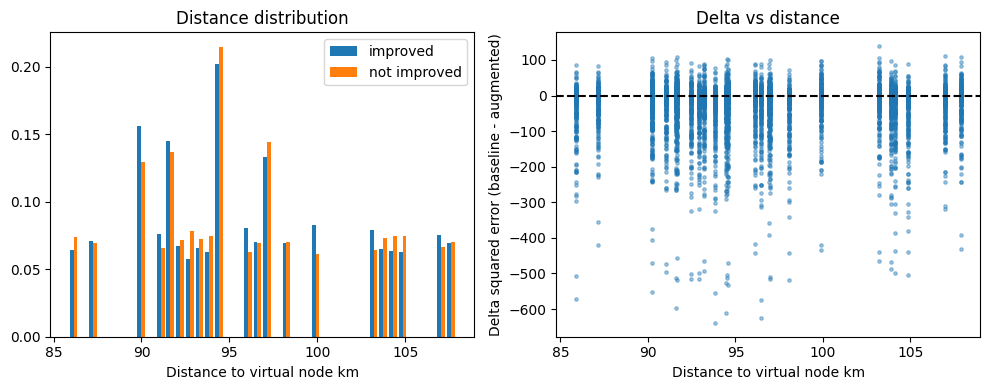

In [12]:
import numpy as np
import copy
import math
import matplotlib.pyplot as plt

# Parameters
k_neighbors_check = 5        # define neighbor by k nearest real nodes
radius_km_check = 10.0       # alternative neighbor definition in kilometers
earth_radius_km = 6371.0

# Haversine distance helper (lon/lat in degrees)
def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

# Builders for baseline and augmented graphs at the chosen virtual location
def baseline_builder(data):
    return build_real_only_graph_copy(data)

aug_builder = make_augmented_builder(best_lat, best_lon)

# Collect per-node records across all samples
records = []  # each record: dict with keys date_t, node_idx, lon, lat, dist_km, delta_sqerr

for sample_idx, data in enumerate(train_samples):
    # baseline and augmented predictions per node
    data_base = baseline_builder(copy.deepcopy(data)).to(device)
    data_aug  = aug_builder(copy.deepcopy(data)).to(device)

    # ensemble predictions (mean)
    def ensemble_preds(ensemble, data_obj):
        preds = []
        for m in ensemble:
            m.eval()
            with torch.no_grad():
                preds.append(m(data_obj).cpu().numpy())
        return np.stack(preds, axis=0).mean(axis=0)

    preds_base = ensemble_preds(real_ensemble, data_base)   # shape (N,)
    preds_aug  = ensemble_preds(virtual_ensemble, data_aug) # shape (N+1,) maybe
    N = data.x.shape[0]
    preds_base_nodes = preds_base[:N]
    preds_aug_nodes  = preds_aug[:N]

    y_true = data.y.cpu().numpy()                          # shape (N,)
    sqerr_base = (preds_base_nodes - y_true)**2
    sqerr_aug  = (preds_aug_nodes  - y_true)**2
    delta = sqerr_base - sqerr_aug                         # positive => improved

    # node coordinates in data.coords are [lon, lat]
    coords = data.coords.cpu().numpy()

    for node_idx in range(N):
        lon_node, lat_node = coords[node_idx]
        dist_km = haversine_km(lon_node, lat_node, best_lon, best_lat)
        records.append({
            "date_t": getattr(data, "date_t", None),
            "sample_idx": sample_idx,
            "node_idx": node_idx,
            "lon": float(lon_node),
            "lat": float(lat_node),
            "dist_km": float(dist_km),
            "delta_sqerr": float(delta[node_idx]),
            "improved": bool(delta[node_idx] > 0.0)
        })

# Convert to structured arrays for analysis
import pandas as pd
df_nodes = pd.DataFrame.from_records(records)

# Basic summary
n_total = len(df_nodes)
n_improved = df_nodes['improved'].sum()
print("Total node instances:", n_total)
print("Improved node instances:", n_improved, f"({n_improved/n_total:.3%})")
print("Mean distance improved:", df_nodes.loc[df_nodes['improved'],'dist_km'].mean())
print("Mean distance not improved:", df_nodes.loc[~df_nodes['improved'],'dist_km'].mean())

# Neighbor definition by k nearest per sample
def label_k_nearest(df, k):
    df = df.copy()
    df['is_k_nearest'] = False
    for sidx in df['sample_idx'].unique():
        sub = df[df['sample_idx']==sidx]
        if sub.shape[0] == 0:
            continue
        idxs = sub['dist_km'].nsmallest(k).index
        df.loc[idxs, 'is_k_nearest'] = True
    return df

df_nodes = label_k_nearest(df_nodes, k_neighbors_check)

# Contingency table: improved vs not improved among k-nearest and others
ct = pd.crosstab(df_nodes['is_k_nearest'], df_nodes['improved'])
print("\nContingency table (rows: is_k_nearest, cols: improved):")
print(ct)

# Fraction improved among neighbors vs non-neighbors
frac_neigh = ct.loc[True, True] / ct.loc[True].sum() if True in ct.index else 0.0
frac_non = ct.loc[False, True] / ct.loc[False].sum() if False in ct.index else 0.0
print(f"\nFraction improved among {k_neighbors_check} nearest: {frac_neigh:.3%}")
print(f"Fraction improved among others: {frac_non:.3%}")

# Statistical test for difference in distances
improved_dists = df_nodes.loc[df_nodes['improved'],'dist_km'].values
notimproved_dists = df_nodes.loc[~df_nodes['improved'],'dist_km'].values

# Use Mann-Whitney U if scipy available, else report means
try:
    from scipy.stats import mannwhitneyu
    stat, pval = mannwhitneyu(improved_dists, notimproved_dists, alternative='less')
    print("\nMann-Whitney U test improved < not improved: stat, p-value:", stat, pval)
except Exception:
    print("\nScipy not available. Mean distances:")
    print("mean improved:", improved_dists.mean(), "mean not improved:", notimproved_dists.mean())

# Visualizations
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist([improved_dists, notimproved_dists], bins=40, label=['improved','not improved'], density=True, stacked=False)
plt.xlabel("Distance to virtual node km")
plt.title("Distance distribution")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(df_nodes['dist_km'], df_nodes['delta_sqerr'], s=6, alpha=0.4)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Distance to virtual node km")
plt.ylabel("Delta squared error (baseline - augmented)")
plt.title("Delta vs distance")
plt.tight_layout()
plt.show()


Using existing df_nodes with 6968 rows

Top 10 stations by fraction improved (station-level consistency):
           lon        lat  n_instances  n_improved  frac_improved  mean_delta
6   126.933502  37.610470          268         127       0.473881  -14.900950
22  127.044853  37.580166          268         127       0.473881  -21.709987
13  127.002327  37.448807          268         124       0.462687  -20.445302
4   126.904968  37.520222          268         121       0.451493  -17.181999
11  126.996780  37.570633          268         118       0.440299  -22.497816
21  127.040939  37.539284          268         117       0.436567  -25.970097
18  127.027267  37.606667          268         116       0.432836  -22.911327
1   126.869812  37.476219          268         115       0.429104  -19.479245
23  127.049683  37.542034          268         112       0.417910  -19.429184
24  127.092384  37.502686          268         109       0.406716  -21.684490

Radius sweep (radius_km, frac_impro

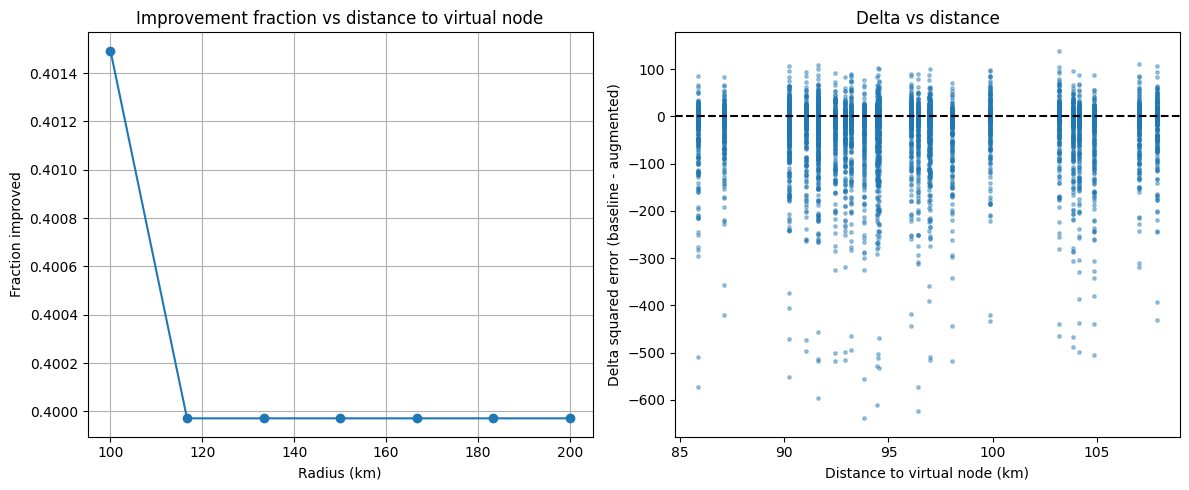

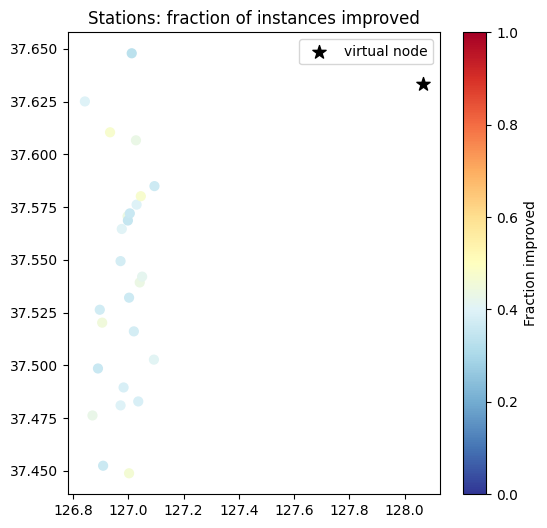


Done. Returned results dict with keys: ['df_nodes', 'station_agg', 'radius_df', 'k_nearest_contingency', 'improved_dists', 'notimproved_dists']


In [13]:
# Single block: per-node records, per-station aggregation, radius sweep, tests, and plots
import numpy as np
import pandas as pd
import copy
import math
import matplotlib.pyplot as plt

# --- Helpers ---
earth_radius_km = 6371.0
def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

def ensemble_preds_mean(ensemble, data_obj):
    preds = []
    for m in ensemble:
        m.eval()
        with torch.no_grad():
            preds.append(m(data_obj).cpu().numpy())
    return np.stack(preds, axis=0).mean(axis=0)

# --- Build df_nodes if missing ---
if 'df_nodes' not in globals():
    print("Building per-node records (this may take a while)...")
    records = []
    # builders
    def baseline_builder(data):
        return build_real_only_graph_copy(data)
    aug_builder = make_augmented_builder(best_lat, best_lon)
    for sample_idx, data in enumerate(train_samples):
        # baseline and augmented graphs
        data_base = baseline_builder(copy.deepcopy(data)).to(device)
        data_aug  = aug_builder(copy.deepcopy(data)).to(device)
        preds_base = ensemble_preds_mean(real_ensemble, data_base)
        preds_aug  = ensemble_preds_mean(virtual_ensemble, data_aug)
        N = data.x.shape[0]
        preds_base_nodes = preds_base[:N]
        preds_aug_nodes  = preds_aug[:N]
        y_true = data.y.cpu().numpy()
        sqerr_base = (preds_base_nodes - y_true)**2
        sqerr_aug  = (preds_aug_nodes  - y_true)**2
        delta = sqerr_base - sqerr_aug
        coords = data.coords.cpu().numpy()  # [lon, lat]
        for node_idx in range(N):
            lon_node, lat_node = coords[node_idx]
            dist_km = haversine_km(lon_node, lat_node, best_lon, best_lat)
            records.append({
                "date_t": getattr(data, "date_t", None),
                "sample_idx": sample_idx,
                "node_idx": node_idx,
                "lon": float(lon_node),
                "lat": float(lat_node),
                "dist_km": float(dist_km),
                "delta_sqerr": float(delta[node_idx]),
                "improved": bool(delta[node_idx] > 0.0)
            })
    df_nodes = pd.DataFrame.from_records(records)
    print("Built df_nodes with", len(df_nodes), "rows")
else:
    print("Using existing df_nodes with", len(df_nodes), "rows")

# --- Aggregate per-station (lon,lat) across dates ---
group_cols = ['lon','lat']
agg = df_nodes.groupby(group_cols).agg(
    n_instances = ('improved','size'),
    n_improved = ('improved','sum'),
    mean_delta = ('delta_sqerr','mean'),
    median_delta = ('delta_sqerr','median'),
    mean_dist = ('dist_km','mean')
).reset_index()
agg['frac_improved'] = agg['n_improved'] / agg['n_instances']

print("\nTop 10 stations by fraction improved (station-level consistency):")
print(agg.sort_values(['frac_improved','mean_delta'], ascending=[False, False]).head(10)[['lon','lat','n_instances','n_improved','frac_improved','mean_delta']])

# --- Radius sweep: fraction improved within radius r ---
radii_km = np.concatenate([np.linspace(0.5,5,10), np.linspace(5,50,10), np.linspace(50,200,10)])
frac_by_radius = []
for r in radii_km:
    mask = df_nodes['dist_km'] <= r
    if mask.sum() == 0:
        frac = np.nan
    else:
        frac = df_nodes.loc[mask,'improved'].mean()
    frac_by_radius.append((float(r), float(frac) if not np.isnan(frac) else np.nan, int(mask.sum())))
radius_df = pd.DataFrame(frac_by_radius, columns=['radius_km','frac_improved','n_points'])
print("\nRadius sweep (radius_km, frac_improved, n_points):")
print(radius_df)

best_row = radius_df.loc[radius_df['frac_improved'].idxmax()]
print("\nBest radius:", best_row['radius_km'], "frac_improved:", best_row['frac_improved'], "n_points:", best_row['n_points'])

# --- Neighbor contingency by k-nearest per sample ---
k_neighbors_check = 5
def label_k_nearest(df, k):
    df = df.copy()
    df['is_k_nearest'] = False
    for sidx in df['sample_idx'].unique():
        sub = df[df['sample_idx']==sidx]
        if sub.shape[0] == 0:
            continue
        idxs = sub['dist_km'].nsmallest(k).index
        df.loc[idxs, 'is_k_nearest'] = True
    return df

df_nodes_kn = label_k_nearest(df_nodes, k_neighbors_check)
ct = pd.crosstab(df_nodes_kn['is_k_nearest'], df_nodes_kn['improved'])
print("\nContingency table (is_k_nearest vs improved):")
print(ct)
frac_neigh = ct.loc[True, True] / ct.loc[True].sum() if True in ct.index else 0.0
frac_non = ct.loc[False, True] / ct.loc[False].sum() if False in ct.index else 0.0
print(f"\nFraction improved among {k_neighbors_check} nearest: {frac_neigh:.3%}")
print(f"Fraction improved among others: {frac_non:.3%}")

# --- Statistical tests on distance distributions ---
improved_dists = df_nodes.loc[df_nodes['improved'],'dist_km'].values
notimproved_dists = df_nodes.loc[~df_nodes['improved'],'dist_km'].values
try:
    from scipy.stats import mannwhitneyu, fisher_exact
    stat, pval = mannwhitneyu(improved_dists, notimproved_dists, alternative='less')
    print("\nMann-Whitney U test (improved < not improved): stat, p-value:", stat, pval)
except Exception:
    print("\nScipy not available; reporting means:")
    print("mean improved dist:", improved_dists.mean(), "mean not improved dist:", notimproved_dists.mean())

# --- Contingency test for a few radii ---
try:
    from scipy.stats import fisher_exact
    for r in [1.0, 5.0, 10.0, 25.0, 50.0]:
        inside = df_nodes['dist_km'] <= r
        ct_r = pd.crosstab(inside, df_nodes['improved'])
        print(f"\nRadius {r} km contingency:")
        print(ct_r)
        if ct_r.shape == (2,2):
            oddsratio, p = fisher_exact(ct_r.values)
            print("Fisher exact oddsratio, p:", oddsratio, p)
except Exception:
    pass

# --- Plots ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(radius_df['radius_km'], radius_df['frac_improved'], marker='o')
plt.xlabel('Radius (km)')
plt.ylabel('Fraction improved')
plt.title('Improvement fraction vs distance to virtual node')
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(df_nodes['dist_km'], df_nodes['delta_sqerr'], s=6, alpha=0.4)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Distance to virtual node (km)")
plt.ylabel("Delta squared error (baseline - augmented)")
plt.title("Delta vs distance")
plt.tight_layout()
plt.show()

# Map of station-level fraction improved (if bbox small enough)
try:
    plt.figure(figsize=(6,6))
    sc = plt.scatter(agg['lon'], agg['lat'], c=agg['frac_improved'], cmap='RdYlBu_r', s=40, vmin=0, vmax=1)
    plt.colorbar(sc, label='Fraction improved')
    plt.scatter([best_lon],[best_lat], c='k', marker='*', s=100, label='virtual node')
    plt.legend()
    plt.title('Stations: fraction of instances improved')
    plt.show()
except Exception:
    pass

# --- Output summary objects for further inspection ---
results = {
    "df_nodes": df_nodes,
    "station_agg": agg,
    "radius_df": radius_df,
    "k_nearest_contingency": ct,
    "improved_dists": improved_dists,
    "notimproved_dists": notimproved_dists
}
print("\nDone. Returned results dict with keys:", list(results.keys()))


One-hop neighbor instances: 6968
Improved instances: 2787 (39.997%)
Mean delta (sqerr base - sqerr aug): -26.4861781697442
Median delta: -1.9442262649536133

Top 10 one-hop stations by fraction improved:
           lon        lat  n_instances  n_improved  frac_improved  mean_delta
6   126.933502  37.610470          268         127       0.473881  -14.900950
22  127.044853  37.580166          268         127       0.473881  -21.709987
13  127.002327  37.448807          268         124       0.462687  -20.445302
4   126.904968  37.520222          268         121       0.451493  -17.181999
11  126.996780  37.570633          268         118       0.440299  -22.497816
21  127.040939  37.539284          268         117       0.436567  -25.970097
18  127.027267  37.606667          268         116       0.432836  -22.911327
1   126.869812  37.476219          268         115       0.429104  -19.479245
23  127.049683  37.542034          268         112       0.417910  -19.429184
24  127.092384  

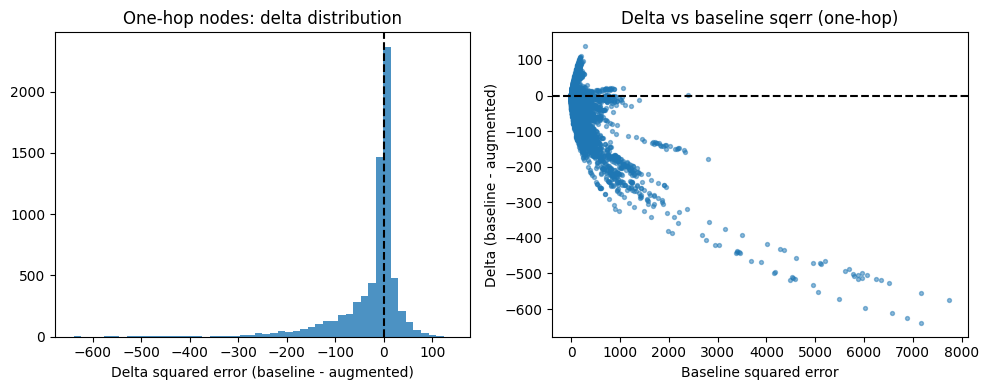


Done. results_onehop keys: ['df_onehop', 'agg_onehop', 'n_total', 'n_improved', 'mean_delta', 'median_delta', 'contingency_table']


In [14]:
# One-hop neighbor analysis: compare baseline vs augmented MSE only for direct neighbors
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
from collections import defaultdict

# Helpers
def ensemble_preds_mean(ensemble, data_obj):
    preds = []
    for m in ensemble:
        m.eval()
        with torch.no_grad():
            preds.append(m(data_obj).cpu().numpy())
    return np.stack(preds, axis=0).mean(axis=0)

# Builders
def baseline_builder(data):
    return build_real_only_graph_copy(data)

def augmented_builder_at(lat, lon):
    def builder(data):
        return build_augmented_graph_latlon(data, lat, lon, list(far_cells), far_cells_meta, unique_coords, mi_weights)
    return builder

aug_builder = augmented_builder_at(best_lat, best_lon)

# Collect per-node one-hop records
records = []
for sample_idx, data in enumerate(train_samples):
    # Build graphs
    data_base = baseline_builder(copy.deepcopy(data)).to(device)
    data_aug  = aug_builder(copy.deepcopy(data)).to(device)

    # Ensemble predictions
    preds_base = ensemble_preds_mean(real_ensemble, data_base)   # shape (N,)
    preds_aug  = ensemble_preds_mean(virtual_ensemble, data_aug) # shape (N+1,) maybe

    N = data.x.shape[0]
    preds_base_nodes = preds_base[:N]
    preds_aug_nodes  = preds_aug[:N]
    y_true = data.y.cpu().numpy()

    # Identify virtual node index and its direct neighbors in data_aug
    # In build_augmented_graph_latlon the virtual node is appended as index N (0-based)
    # edge_index shape: (2, E)
    edge_index = data_aug.edge_index.cpu().numpy()
    srcs, dsts = edge_index[0], edge_index[1]
    v_idx = N  # virtual node index
    # neighbors are nodes that have an edge to/from v_idx
    neigh_mask = (srcs == v_idx) | (dsts == v_idx)
    neigh_nodes = set()
    for s, d, m in zip(srcs, dsts, neigh_mask):
        if m:
            # the other endpoint
            other = d if s == v_idx else s
            if other < N:  # only real nodes
                neigh_nodes.add(int(other))

    # compute per-node squared errors and delta for neighbors only
    sqerr_base = (preds_base_nodes - y_true)**2
    sqerr_aug  = (preds_aug_nodes  - y_true)**2
    delta = sqerr_base - sqerr_aug  # positive => improved

    coords = data.coords.cpu().numpy()  # [lon, lat]
    for node_idx in sorted(neigh_nodes):
        lon_node, lat_node = coords[node_idx]
        records.append({
            "sample_idx": sample_idx,
            "date_t": getattr(data, "date_t", None),
            "node_idx": int(node_idx),
            "lon": float(lon_node),
            "lat": float(lat_node),
            "sqerr_base": float(sqerr_base[node_idx]),
            "sqerr_aug": float(sqerr_aug[node_idx]),
            "delta_sqerr": float(delta[node_idx]),
            "improved": bool(delta[node_idx] > 0.0)
        })

# Build DataFrame
df_onehop = pd.DataFrame.from_records(records)
n_total = len(df_onehop)
n_improved = df_onehop['improved'].sum()
mean_delta = df_onehop['delta_sqerr'].mean() if n_total>0 else np.nan
median_delta = df_onehop['delta_sqerr'].median() if n_total>0 else np.nan

print("One-hop neighbor instances:", n_total)
print("Improved instances:", n_improved, f"({n_improved/n_total:.3%})")
print("Mean delta (sqerr base - sqerr aug):", mean_delta)
print("Median delta:", median_delta)

# Per-station aggregation (for nodes that were ever one-hop)
agg_onehop = df_onehop.groupby(['lon','lat']).agg(
    n_instances=('improved','size'),
    n_improved=('improved','sum'),
    mean_delta=('delta_sqerr','mean'),
    median_delta=('delta_sqerr','median')
).reset_index()
agg_onehop['frac_improved'] = agg_onehop['n_improved'] / agg_onehop['n_instances']

print("\nTop 10 one-hop stations by fraction improved:")
print(agg_onehop.sort_values(['frac_improved','mean_delta'], ascending=[False, False]).head(10)[['lon','lat','n_instances','n_improved','frac_improved','mean_delta']])

# Statistical test: are one-hop nodes more likely to improve than non-one-hop nodes?
# Build label for all node-instances (we already have df_nodes from earlier runs if present)
if 'df_nodes' in globals():
    # mark one-hop membership
    df_nodes_copy = df_nodes.copy()
    # create a key to match lon/lat and sample_idx/node_idx
    df_nodes_copy['key'] = df_nodes_copy['sample_idx'].astype(str) + "_" + df_nodes_copy['node_idx'].astype(str)
    df_onehop['key'] = df_onehop['sample_idx'].astype(str) + "_" + df_onehop['node_idx'].astype(str)
    onehop_keys = set(df_onehop['key'].tolist())
    df_nodes_copy['is_onehop'] = df_nodes_copy['key'].isin(onehop_keys)
    # contingency
    ct = pd.crosstab(df_nodes_copy['is_onehop'], df_nodes_copy['improved'])
    print("\nContingency table (is_onehop vs improved):")
    print(ct)
else:
    print("\nNote: df_nodes (all node-instances) not found in globals; skipping global contingency test.")

# Plots: histogram of delta and scatter of delta vs baseline sqerr for one-hop nodes
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df_onehop['delta_sqerr'].dropna(), bins=50, color='C0', alpha=0.8)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Delta squared error (baseline - augmented)')
plt.title('One-hop nodes: delta distribution')

plt.subplot(1,2,2)
plt.scatter(df_onehop['sqerr_base'], df_onehop['delta_sqerr'], s=8, alpha=0.5)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Baseline squared error')
plt.ylabel('Delta (baseline - augmented)')
plt.title('Delta vs baseline sqerr (one-hop)')
plt.tight_layout()
plt.show()

# Return results dict for further inspection
results_onehop = {
    "df_onehop": df_onehop,
    "agg_onehop": agg_onehop,
    "n_total": n_total,
    "n_improved": n_improved,
    "mean_delta": mean_delta,
    "median_delta": median_delta,
    "contingency_table": ct if 'ct' in locals() else None
}
print("\nDone. results_onehop keys:", list(results_onehop.keys()))


In [15]:
# === Bias correction + standardization + retrain pipeline ===
import numpy as np
import pandas as pd
import copy
import math
from collections import defaultdict

# --- Config (adjust if your variable names differ) ---
station_date_col = "date"           # in grouped
station_lon_col = "station_lon"
station_lat_col = "station_lat"
station_target_col = "value"        # target in grouped
daily_vars = daily_vars             # from your environment (list of strings)
local_feature_cols = local_feature_cols  # from your environment (list of strings)

# --- Helpers ---
def nearest_cell_for_point(lon, lat, cells_idx_list):
    # cells_idx_list: list of tuples (cell_idx, entry) where entry has 'lon','lat'
    # returns cell_idx with min squared lon/lat distance
    best = None
    best_d2 = float("inf")
    for ci, entry in cells_idx_list:
        d2 = (entry['lon'] - lon)**2 + (entry['lat'] - lat)**2
        if d2 < best_d2:
            best_d2 = d2
            best = ci
    return best

def build_cells_index_for_date(d):
    # returns list of (cell_idx, entry) for date d
    cells = data_by_day.get(d, {})
    return [(ci, cells[ci]) for ci in cells.keys()]

# --- 1) Estimate per-variable bias between station obs and nearest grid cell ---
print("Step 1: estimating bias between station observations and nearest grid cell values...")

# Prepare grouped copy and ensure date strings match keys in data_by_day
g = grouped.copy()
g[station_date_col] = pd.to_datetime(g[station_date_col]).dt.date
g['date_iso'] = g[station_date_col].astype(str)

# Collect matched pairs per variable
pairs = {var: [] for var in daily_vars}
pairs_count = 0

# Precompute a list of available dates in data_by_day for quick membership test
available_dates = set(data_by_day.keys())

for idx, row in g.iterrows():
    d_iso = row['date_iso']
    if d_iso not in available_dates:
        continue
    # find nearest cell to station for that date
    cells_list = build_cells_index_for_date(d_iso)
    if len(cells_list) == 0:
        continue
    lon_s = float(row[station_lon_col])
    lat_s = float(row[station_lat_col])
    best_ci = nearest_cell_for_point(lon_s, lat_s, cells_list)
    if best_ci is None:
        continue
    entry = data_by_day[d_iso].get(best_ci)
    if entry is None:
        continue
    # for each daily var, if both station and cell have values, record pair
    for var in daily_vars:
        # station side: try to find matching station variable name in grouped
        # We assume station observations for these variables exist in grouped with same var names.
        if var in g.columns:
            s_val = row[var]
        else:
            # if station doesn't have that var, skip
            s_val = np.nan
        c_val = entry.get(var, np.nan)
        if not pd.isna(s_val) and not pd.isna(c_val):
            pairs[var].append((float(s_val), float(c_val)))
            pairs_count += 1

print("Collected matched pairs (total pairs across vars):", pairs_count)

# Compute bias per variable as mean(station - cell)
bias = {}
for var, lst in pairs.items():
    if len(lst) == 0:
        bias[var] = 0.0
    else:
        arr = np.array(lst, dtype=np.float32)
        diff = arr[:,0] - arr[:,1]
        bias[var] = float(np.nanmean(diff))
print("Estimated bias (station - grid) for variables:")
for var in daily_vars:
    print(f"  {var}: {bias.get(var,0.0):.4f}")

# --- 2) Apply bias correction to data_by_day (in-place corrected copy) ---
print("\nStep 2: applying bias correction to data_by_day (creating corrected_data_by_day)...")
corrected_data_by_day = {}
for d_iso, cells in data_by_day.items():
    corrected_cells = {}
    for ci, entry in cells.items():
        corrected_entry = entry.copy()
        for var in daily_vars:
            if var in entry and entry[var] is not None:
                # subtract bias (station - grid) => corrected_grid = grid + bias_estimate
                # We want corrected grid to be closer to station: corrected = grid + bias
                corrected_entry[var] = entry[var] + bias.get(var, 0.0)
        corrected_cells[ci] = corrected_entry
    corrected_data_by_day[d_iso] = corrected_cells

# Replace data_by_day reference for downstream steps (keep original as backup)
data_by_day_orig = data_by_day
data_by_day = corrected_data_by_day
print("Bias correction applied. data_by_day replaced with corrected copy.")

# --- 2b) Standardize (z-score) corrected daily_vars across all dates/cells ---
print("\nStep 2b: computing global mean/std and standardizing daily_vars in data_by_day and station features...")

# gather all corrected values per var
vals = {var: [] for var in daily_vars}
for d_iso, cells in data_by_day.items():
    for ci, entry in cells.items():
        for var in daily_vars:
            v = entry.get(var)
            if v is None or (isinstance(v, float) and np.isnan(v)):
                continue
            vals[var].append(float(v))
# compute mean/std
mean_std = {}
for var in daily_vars:
    arr = np.array(vals[var], dtype=np.float32) if len(vals[var])>0 else np.array([0.0], dtype=np.float32)
    mu = float(np.nanmean(arr))
    sigma = float(np.nanstd(arr, ddof=0))
    if sigma == 0 or np.isnan(sigma):
        sigma = 1.0
    mean_std[var] = (mu, sigma)
    print(f"  {var}: mean={mu:.4f}, std={sigma:.4f}")

# apply z-score to data_by_day entries (overwrite with standardized values)
for d_iso, cells in data_by_day.items():
    for ci, entry in cells.items():
        for var in daily_vars:
            v = entry.get(var)
            if v is None or (isinstance(v, float) and np.isnan(v)):
                entry[var] = np.nan
            else:
                mu, sigma = mean_std[var]
                entry[var] = (float(v) - mu) / sigma
    # assign back
    data_by_day[d_iso] = cells

print("Standardized daily_vars in data_by_day.")

# Also standardize station local features in grouped (so GNN real features are on same scale)
print("Standardizing station local features in 'grouped' DataFrame...")
g2 = grouped.copy()
# ensure grouped has the same local_feature_cols; if not, skip missing ones
for col in local_feature_cols:
    if col in g2.columns:
        # compute mean/std from grouped (station side)
        arr = g2[col].dropna().astype(float).values
        if len(arr) == 0:
            mu, sigma = 0.0, 1.0
        else:
            mu, sigma = float(np.nanmean(arr)), float(np.nanstd(arr, ddof=0))
            if sigma == 0 or np.isnan(sigma):
                sigma = 1.0
        g2[col] = g2[col].astype(float).map(lambda x: (x - mu)/sigma if not pd.isna(x) else np.nan)
        print(f"  standardized {col}: mu={mu:.4f}, std={sigma:.4f}")
    else:
        print(f"  warning: station feature {col} not found in grouped; skipping standardization for it.")
# replace grouped for downstream pipeline
grouped_orig = grouped
grouped = g2
print("Station local features standardized in grouped.")

# --- 3) Recompute MI weights using corrected/standardized data_by_day ---
print("\nStep 3: recomputing MI weights using corrected/standardized predictors...")

# Re-prepare train_samples and daily_real using the standardized grouped and corrected data_by_day
train_samples, usable_dates, daily_real = prepare_train_samples(grouped)
print("Prepared", len(train_samples), "train samples and", len(usable_dates), "usable dates (after standardization).")

# Recompute far_cells_meta (ensure bbox matches)
far_cells_meta = select_far_cells(grid_centers, LON_MIN, LON_MAX, LAT_MIN, LAT_MAX)
far_cells = list(far_cells_meta.keys())
print("Num far cells in bbox:", len(far_cells))

# infer daily_vars again (should be same names)
sample_day = next(iter(data_by_day.keys()))
sample_cell = next(iter(data_by_day[sample_day].values()))
daily_vars = [k for k in sample_cell.keys() if k not in ("lon","lat")]

unique_coords, mi_weights = compute_mi_weights(daily_real, usable_dates, far_cells, data_by_day, daily_vars)
print("Computed MI weights shape:", mi_weights.shape)

# --- 4) Retrain ensembles (real-only and virtual) and evaluate ---
print("\nRetraining ensembles and evaluating...")

# Train real-only ensemble
real_ensemble = train_real_only_ensemble(train_samples, epochs=15, ensemble_size=ensemble_size)
print("Trained real-only ensemble.")

# Train virtual ensemble (random virtual node during training)
virtual_ensemble = train_virtual_ensemble(train_samples, unique_coords, mi_weights, far_cells, far_cells_meta, epochs=15, ensemble_size=ensemble_size)
print("Trained virtual-node ensemble.")

# Coarse search and refinement using virtual ensemble
best_cell, best_mse = coarse_search_best_cell(virtual_ensemble, train_samples, far_cells_meta, unique_coords, mi_weights, far_cells)
print("Coarse best cell:", best_cell, "MSE:", best_mse)
lat0 = far_cells_meta[best_cell]["lat"]
lon0 = far_cells_meta[best_cell]["lon"]

best_lat, best_lon, best_val = refine_latlon(virtual_ensemble, train_samples, lat0, lon0, unique_coords, mi_weights, far_cells, far_cells_meta)
print("Refined lat/lon:", best_lat, best_lon, "MSE:", best_val)

# Evaluate both ensembles on train_samples (or replace with held-out set if available)
def evaluate_ensemble(ensemble, samples, builder_fn):
    mses = []
    for data in samples:
        data_graph = builder_fn(copy.deepcopy(data)).to(device)
        preds = ensemble_predict_mean(ensemble, data_graph)
        N = data.x.shape[0]
        mse = float(np.mean((preds[:N] - data.y.cpu().numpy())**2))
        mses.append(mse)
    return np.array(mses)

baseline_mses = evaluate_ensemble(real_ensemble, train_samples, lambda d: build_real_only_graph_copy(d))
aug_mses_refined = evaluate_ensemble(virtual_ensemble, train_samples, make_augmented_builder(best_lat, best_lon))

print("\nEvaluation summary after bias correction + standardization:")
print("Baseline mean MSE (real-only):", float(np.mean(baseline_mses)))
print("Virtual ensemble mean MSE (augmented at refined):", float(np.mean(aug_mses_refined)))
print("Mean absolute improvement (baseline - augmented):", float(np.mean(baseline_mses - aug_mses_refined)))
print("Fraction samples improved:", float(np.mean((baseline_mses - aug_mses_refined) > 0.0)))

# --- 5) Re-run one-hop neighbor analysis (optional) ---
print("\nRecomputing one-hop neighbor analysis (summary)...")
# reuse the one-hop block you ran earlier or call the function if you wrapped it; here we compute a quick summary:
# For speed, compute per-sample N MSE deltas for one-hop nodes only
onehop_records = []
for sample_idx, data in enumerate(train_samples):
    data_base = build_real_only_graph_copy(copy.deepcopy(data)).to(device)
    data_aug = build_augmented_graph_latlon(copy.deepcopy(data), best_lat, best_lon, list(far_cells), far_cells_meta, unique_coords, mi_weights).to(device)
    preds_base = ensemble_predict_mean(real_ensemble, data_base)[:data.x.shape[0]]
    preds_aug = ensemble_predict_mean(virtual_ensemble, data_aug)[:data.x.shape[0]]
    y_true = data.y.cpu().numpy()
    sq_base = (preds_base - y_true)**2
    sq_aug = (preds_aug - y_true)**2
    delta = sq_base - sq_aug
    # find neighbors of virtual node in data_aug
    edge_index = data_aug.edge_index.cpu().numpy()
    srcs, dsts = edge_index[0], edge_index[1]
    v_idx = data.x.shape[0]
    neigh_mask = (srcs == v_idx) | (dsts == v_idx)
    neigh_nodes = set()
    for s,d,m in zip(srcs, dsts, neigh_mask):
        if m:
            other = d if s == v_idx else s
            if other < data.x.shape[0]:
                neigh_nodes.add(int(other))
    for ni in neigh_nodes:
        onehop_records.append(delta[ni])
onehop_records = np.array(onehop_records)
print("One-hop instances after correction:", len(onehop_records))
print("Mean delta (baseline - augmented) for one-hop:", float(np.nanmean(onehop_records)))
print("Fraction one-hop improved:", float(np.mean(onehop_records > 0.0)))

# Done
print("\nPipeline finished. Key objects updated in the environment:")
print("  data_by_day (corrected & standardized), grouped (standardized),")
print("  unique_coords, mi_weights, real_ensemble, virtual_ensemble, best_lat, best_lon")


Step 1: estimating bias between station observations and nearest grid cell values...
Collected matched pairs (total pairs across vars): 0
Estimated bias (station - grid) for variables:
  temperature_2m_mean: 0.0000
  relative_humidity_2m_mean: 0.0000
  dew_point_2m_mean: 0.0000
  windspeed_10m_mean: 0.0000
  winddirection_10m_dominant: 0.0000
  surface_pressure_mean: 0.0000
  precipitation_sum: 0.0000

Step 2: applying bias correction to data_by_day (creating corrected_data_by_day)...
Bias correction applied. data_by_day replaced with corrected copy.

Step 2b: computing global mean/std and standardizing daily_vars in data_by_day and station features...
  temperature_2m_mean: mean=11.6525, std=12.0919
  relative_humidity_2m_mean: mean=69.1097, std=14.2975
  dew_point_2m_mean: mean=5.5801, std=13.1697
  windspeed_10m_mean: mean=8.1140, std=3.3968
  winddirection_10m_dominant: mean=225.5671, std=76.8332
  surface_pressure_mean: mean=1005.9343, std=14.8090
  precipitation_sum: mean=3.0778,

Total node instances: 6968
Improved node instances: 4788 (68.714%)
Mean distance improved: 83.60642226059731
Mean distance not improved: 83.39073334453686

Contingency table (rows: is_k_nearest, cols: improved):
improved      False  True 
is_k_nearest              
False          1770   3858
True            410    930

Fraction improved among 5 nearest: 69.403%
Fraction improved among others: 68.550%

Mann-Whitney U test improved < not improved: stat, p-value: 5350776.0 0.9549450263359651


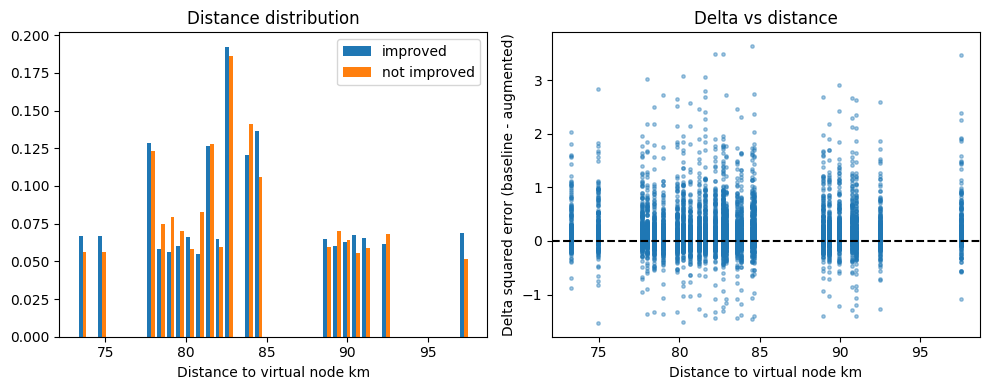

In [16]:
import numpy as np
import copy
import math
import matplotlib.pyplot as plt

# Parameters
k_neighbors_check = 5        # define neighbor by k nearest real nodes
radius_km_check = 10.0       # alternative neighbor definition in kilometers
earth_radius_km = 6371.0

# Haversine distance helper (lon/lat in degrees)
def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

# Builders for baseline and augmented graphs at the chosen virtual location
def baseline_builder(data):
    return build_real_only_graph_copy(data)

aug_builder = make_augmented_builder(best_lat, best_lon)

# Collect per-node records across all samples
records = []  # each record: dict with keys date_t, node_idx, lon, lat, dist_km, delta_sqerr

for sample_idx, data in enumerate(train_samples):
    # baseline and augmented predictions per node
    data_base = baseline_builder(copy.deepcopy(data)).to(device)
    data_aug  = aug_builder(copy.deepcopy(data)).to(device)

    # ensemble predictions (mean)
    def ensemble_preds(ensemble, data_obj):
        preds = []
        for m in ensemble:
            m.eval()
            with torch.no_grad():
                preds.append(m(data_obj).cpu().numpy())
        return np.stack(preds, axis=0).mean(axis=0)

    preds_base = ensemble_preds(real_ensemble, data_base)   # shape (N,)
    preds_aug  = ensemble_preds(virtual_ensemble, data_aug) # shape (N+1,) maybe
    N = data.x.shape[0]
    preds_base_nodes = preds_base[:N]
    preds_aug_nodes  = preds_aug[:N]

    y_true = data.y.cpu().numpy()                          # shape (N,)
    sqerr_base = (preds_base_nodes - y_true)**2
    sqerr_aug  = (preds_aug_nodes  - y_true)**2
    delta = sqerr_base - sqerr_aug                         # positive => improved

    # node coordinates in data.coords are [lon, lat]
    coords = data.coords.cpu().numpy()

    for node_idx in range(N):
        lon_node, lat_node = coords[node_idx]
        dist_km = haversine_km(lon_node, lat_node, best_lon, best_lat)
        records.append({
            "date_t": getattr(data, "date_t", None),
            "sample_idx": sample_idx,
            "node_idx": node_idx,
            "lon": float(lon_node),
            "lat": float(lat_node),
            "dist_km": float(dist_km),
            "delta_sqerr": float(delta[node_idx]),
            "improved": bool(delta[node_idx] > 0.0)
        })

# Convert to structured arrays for analysis
import pandas as pd
df_nodes = pd.DataFrame.from_records(records)

# Basic summary
n_total = len(df_nodes)
n_improved = df_nodes['improved'].sum()
print("Total node instances:", n_total)
print("Improved node instances:", n_improved, f"({n_improved/n_total:.3%})")
print("Mean distance improved:", df_nodes.loc[df_nodes['improved'],'dist_km'].mean())
print("Mean distance not improved:", df_nodes.loc[~df_nodes['improved'],'dist_km'].mean())

# Neighbor definition by k nearest per sample
def label_k_nearest(df, k):
    df = df.copy()
    df['is_k_nearest'] = False
    for sidx in df['sample_idx'].unique():
        sub = df[df['sample_idx']==sidx]
        if sub.shape[0] == 0:
            continue
        idxs = sub['dist_km'].nsmallest(k).index
        df.loc[idxs, 'is_k_nearest'] = True
    return df

df_nodes = label_k_nearest(df_nodes, k_neighbors_check)

# Contingency table: improved vs not improved among k-nearest and others
ct = pd.crosstab(df_nodes['is_k_nearest'], df_nodes['improved'])
print("\nContingency table (rows: is_k_nearest, cols: improved):")
print(ct)

# Fraction improved among neighbors vs non-neighbors
frac_neigh = ct.loc[True, True] / ct.loc[True].sum() if True in ct.index else 0.0
frac_non = ct.loc[False, True] / ct.loc[False].sum() if False in ct.index else 0.0
print(f"\nFraction improved among {k_neighbors_check} nearest: {frac_neigh:.3%}")
print(f"Fraction improved among others: {frac_non:.3%}")

# Statistical test for difference in distances
improved_dists = df_nodes.loc[df_nodes['improved'],'dist_km'].values
notimproved_dists = df_nodes.loc[~df_nodes['improved'],'dist_km'].values

# Use Mann-Whitney U if scipy available, else report means
try:
    from scipy.stats import mannwhitneyu
    stat, pval = mannwhitneyu(improved_dists, notimproved_dists, alternative='less')
    print("\nMann-Whitney U test improved < not improved: stat, p-value:", stat, pval)
except Exception:
    print("\nScipy not available. Mean distances:")
    print("mean improved:", improved_dists.mean(), "mean not improved:", notimproved_dists.mean())

# Visualizations
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist([improved_dists, notimproved_dists], bins=40, label=['improved','not improved'], density=True, stacked=False)
plt.xlabel("Distance to virtual node km")
plt.title("Distance distribution")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(df_nodes['dist_km'], df_nodes['delta_sqerr'], s=6, alpha=0.4)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Distance to virtual node km")
plt.ylabel("Delta squared error (baseline - augmented)")
plt.title("Delta vs distance")
plt.tight_layout()
plt.show()


In [17]:
import numpy as np
from scipy.stats import wilcoxon, ttest_rel
rng = np.random.default_rng(0)

# 1) Per-sample deltas
deltas = baseline_mses - aug_mses_refined   # positive => improvement
n = len(deltas)
mean_delta = float(np.nanmean(deltas))
median_delta = float(np.nanmedian(deltas))
frac_improved = float(np.mean(deltas > 0.0))

# 2) Paired tests
w_stat, w_p = wilcoxon(deltas)
t_stat, t_p = ttest_rel(baseline_mses, aug_mses_refined)

# 3) Cohen's d (paired)
diff = deltas
d_mean = diff.mean()
d_std = diff.std(ddof=1)
cohens_d = float(d_mean / d_std) if d_std > 0 else float('nan')

# 4) Bootstrap 95% CI for mean delta
B = 2000
boot_means = []
for _ in range(B):
    idx = rng.integers(0, n, n)
    boot_means.append(deltas[idx].mean())
ci_lower, ci_upper = np.percentile(boot_means, [2.5, 97.5])

print("N:", n)
print("Mean delta:", mean_delta)
print("Median delta:", median_delta)
print("Fraction improved:", frac_improved)
print("Wilcoxon p:", w_p, "Paired t p:", t_p)
print("Cohen's d:", cohens_d)
print("Bootstrap 95% CI for mean delta:", (ci_lower, ci_upper))

# 5) One-hop summary (if df_onehop exists with column delta_sqerr)
if 'df_onehop' in globals():
    onehop_deltas = df_onehop['delta_sqerr'].values
    print("One-hop N:", len(onehop_deltas))
    print("One-hop mean delta:", float(np.nanmean(onehop_deltas)))
    print("One-hop fraction improved:", float(np.mean(onehop_deltas > 0.0)))


N: 268
Mean delta: 0.1735175130402308
Median delta: 0.08302876353263855
Fraction improved: 0.7388059701492538
Wilcoxon p: 4.3037906048920274e-17 Paired t p: 8.092020783003302e-13
Cohen's d: 0.4596615239807724
Bootstrap 95% CI for mean delta: (np.float64(0.1283687464543618), np.float64(0.2189745811446667))
One-hop N: 6968
One-hop mean delta: -26.4861781697442
One-hop fraction improved: 0.39997129735935705


In [ ]:
# -------------------------
# Fixed-location virtual retrain + comparison
# -------------------------
import copy
import numpy as np
from scipy.stats import wilcoxon, ttest_rel
import torch
import torch.nn as nn

# Config (adjust if you want fewer epochs for quick iteration)
EPOCHS = 15
ENSEMBLE_SIZE = 3
LR = 1e-3

# Helper: train one model with virtual node fixed at (lat, lon)
def train_one_model_fixed_virtual(train_samples, lat, lon, epochs=EPOCHS, lr=LR):
    in_channels = train_samples[0].x.shape[1]
    model = GATSpatioTemporal(in_channels=in_channels, hidden=64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        for data in train_samples:
            data_aug = build_augmented_graph_latlon(data, lat, lon, list(far_cells), far_cells_meta, unique_coords, mi_weights)
            opt.zero_grad()
            out = model(data_aug)
            N = data.x.shape[0]
            loss = loss_fn(out[:N], data.y)
            loss.backward()
            opt.step()
    return model

def train_fixed_virtual_ensemble(train_samples, lat, lon, ensemble_size=ENSEMBLE_SIZE, epochs=EPOCHS):
    ensemble = []
    for i in range(ensemble_size):
        m = train_one_model_fixed_virtual(train_samples, lat, lon, epochs=epochs)
        ensemble.append(m)
    return ensemble

# Train fixed-virtual ensemble
print("Training fixed-location virtual ensemble at refined location:", best_lat, best_lon)
fixed_ensemble = train_fixed_virtual_ensemble(train_samples, best_lat, best_lon, ensemble_size=ENSEMBLE_SIZE, epochs=EPOCHS)
print("Trained fixed-location ensemble of size:", len(fixed_ensemble))

# Ensure we have real-only and random-virtual ensembles; train if missing
if 'real_ensemble' not in globals():
    print("Training real-only ensemble (was not found)...")
    real_ensemble = train_real_only_ensemble(train_samples, epochs=EPOCHS, ensemble_size=ENSEMBLE_SIZE)
if 'virtual_ensemble' not in globals():
    print("Training random-virtual ensemble (was not found)...")
    virtual_ensemble = train_virtual_ensemble(train_samples, unique_coords, mi_weights, far_cells, far_cells_meta, epochs=EPOCHS, ensemble_size=ENSEMBLE_SIZE)

# Evaluation helper: compute per-sample MSEs for an ensemble and a builder function
def evaluate_ensemble_mses(ensemble, samples, builder_fn):
    mses = []
    for data in samples:
        data_graph = builder_fn(copy.deepcopy(data)).to(device)
        preds = ensemble_predict_mean(ensemble, data_graph)
        N = data.x.shape[0]
        mse = float(np.mean((preds[:N] - data.y.cpu().numpy())**2))
        mses.append(mse)
    return np.array(mses)

# Builders
real_builder = lambda d: build_real_only_graph_copy(d)
rand_builder = lambda d: make_augmented_builder(np.random.uniform(LAT_MIN, LAT_MAX), np.random.uniform(LON_MIN, LON_MAX))(d)  # not used for eval
fixed_builder = lambda d: build_augmented_graph_latlon(d, best_lat, best_lon, list(far_cells), far_cells_meta, unique_coords, mi_weights)

# Evaluate ensembles on the same samples
print("Evaluating ensembles on samples...")
baseline_mses = evaluate_ensemble_mses(real_ensemble, train_samples, real_builder)
random_virtual_mses = evaluate_ensemble_mses(virtual_ensemble, train_samples, lambda d: build_augmented_graph_latlon(d, np.random.uniform(LAT_MIN, LAT_MAX), np.random.uniform(LON_MIN, LON_MAX), list(far_cells), far_cells_meta, unique_coords, mi_weights))
fixed_virtual_mses = evaluate_ensemble_mses(fixed_ensemble, train_samples, fixed_builder)

# For a fair comparison of random_virtual, we should evaluate the existing trained random ensemble at the refined location:
random_at_refined_mses = evaluate_ensemble_mses(virtual_ensemble, train_samples, fixed_builder)

# Comparison function: paired stats and bootstrap CI
def compare_mses(base_mses, aug_mses, label):
    deltas = base_mses - aug_mses
    n = len(deltas)
    mean_delta = float(np.nanmean(deltas))
    median_delta = float(np.nanmedian(deltas))
    frac_improved = float(np.mean(deltas > 0.0))
    try:
        w_stat, w_p = wilcoxon(deltas)
    except Exception:
        w_stat, w_p = (np.nan, np.nan)
    t_stat, t_p = ttest_rel(base_mses, aug_mses)
    # Cohen's d (paired)
    d_mean = deltas.mean()
    d_std = deltas.std(ddof=1)
    cohens_d = float(d_mean / d_std) if d_std > 0 else float('nan')
    # bootstrap CI
    rng = np.random.default_rng(0)
    B = 2000
    boot_means = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        boot_means.append(deltas[idx].mean())
    ci_lower, ci_upper = np.percentile(boot_means, [2.5, 97.5])
    print(f"\n=== Comparison: baseline vs {label} ===")
    print(f"N samples: {n}")
    print(f"Mean delta (baseline - {label}): {mean_delta:.6f}")
    print(f"Median delta: {median_delta:.6f}")
    print(f"Fraction improved: {frac_improved:.3%}")
    print(f"Wilcoxon p: {w_p:.4e}, Paired t p: {t_p:.4e}")
    print(f"Cohen's d (paired): {cohens_d:.4f}")
    print(f"Bootstrap 95% CI for mean delta: [{ci_lower:.6f}, {ci_upper:.6f}]")
    return {
        "mean_delta": mean_delta,
        "median_delta": median_delta,
        "frac_improved": frac_improved,
        "wilcoxon_p": w_p,
        "ttest_p": t_p,
        "cohens_d": cohens_d,
        "ci": (ci_lower, ci_upper)
    }

# Run comparisons
res_random_at_refined = compare_mses(baseline_mses, random_at_refined_mses, "random-virtual @ refined")
res_fixed = compare_mses(baseline_mses, fixed_virtual_mses, "fixed-virtual @ refined")
res_random_original = compare_mses(baseline_mses, random_virtual_mses, "random-virtual (random locations)")

# One-hop summary for fixed ensemble (direct neighbors only)
print("\nOne-hop neighbor summary for fixed-virtual ensemble:")
onehop_deltas = []
for data in train_samples:
    data_base = build_real_only_graph_copy(copy.deepcopy(data)).to(device)
    data_fixed = build_augmented_graph_latlon(copy.deepcopy(data), best_lat, best_lon, list(far_cells), far_cells_meta, unique_coords, mi_weights).to(device)
    pred_base = ensemble_predict_mean(real_ensemble, data_base)[:data.x.shape[0]]
    pred_fixed = ensemble_predict_mean(fixed_ensemble, data_fixed)[:data.x.shape[0]]
    y = data.y.cpu().numpy()
    sq_base = (pred_base - y)**2
    sq_fixed = (pred_fixed - y)**2
    delta_node = sq_base - sq_fixed
    # find neighbors of virtual node
    edge_index = data_fixed.edge_index.cpu().numpy()
    srcs, dsts = edge_index[0], edge_index[1]
    N = data.x.shape[0]
    v_idx = N
    neigh_nodes = set()
    for s,d in zip(srcs, dsts):
        if s == v_idx and d < N:
            neigh_nodes.add(int(d))
        if d == v_idx and s < N:
            neigh_nodes.add(int(s))
    for ni in neigh_nodes:
        onehop_deltas.append(delta_node[ni])
onehop_deltas = np.array(onehop_deltas)
print("One-hop instances (fixed):", len(onehop_deltas))
print("One-hop mean delta (baseline - fixed):", float(np.nanmean(onehop_deltas)))
print("One-hop fraction improved (fixed):", float(np.mean(onehop_deltas > 0.0)))

# Save results for inspection
fixed_retrain_results = {
    "baseline_mses": baseline_mses,
    "random_at_refined_mses": random_at_refined_mses,
    "fixed_virtual_mses": fixed_virtual_mses,
    "random_virtual_mses": random_virtual_mses,
    "res_random_at_refined": res_random_at_refined,
    "res_fixed": res_fixed,
    "res_random_original": res_random_original,
    "onehop_deltas_fixed": onehop_deltas
}

print("\nFixed-location retrain and evaluation complete. Results stored in `fixed_retrain_results`.")


Training fixed-location virtual ensemble at refined location: 37.41022642091529 127.91434604263645
Trained fixed-location ensemble of size: 3
Evaluating ensembles on samples...
